<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW4_woodenML_base_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 4 (base): древесные алгоритмы**

### **Постановка задачи:**

У вас есть данные о полетах, обладающие следущими характеристиками:
- Для **каждого** клиента известна краткая информация о самом человеке, о типе билета и о рейсе, а также оценки клиента различным аспектам полета.
- Для **некоторых** клиентов известна их удовлетворенность полетом (satisfied или neutral or dissatisfied).

По данным необходимо обучить модель, предсказывающую удовлетворенность клиентов полетом. Итоговые предсказания нужно сделать для клиентов, **для которых ответ неизвестен.**

### **Получение данных:**

Компания держит все данные в облаке Яндекса в Postgresql. Данные разбиты на смысловые таблицы. Чтобы получить данные, вам необходимо подключиться к базе данных и добыть оттуда данные.

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 0.7 бонусных баллов.

Оценка за ДЗ = min{ваш балл, 10}

Мягкий дедлайн: 29 января 23:59

**Продуктивной и интересной вам работы!**

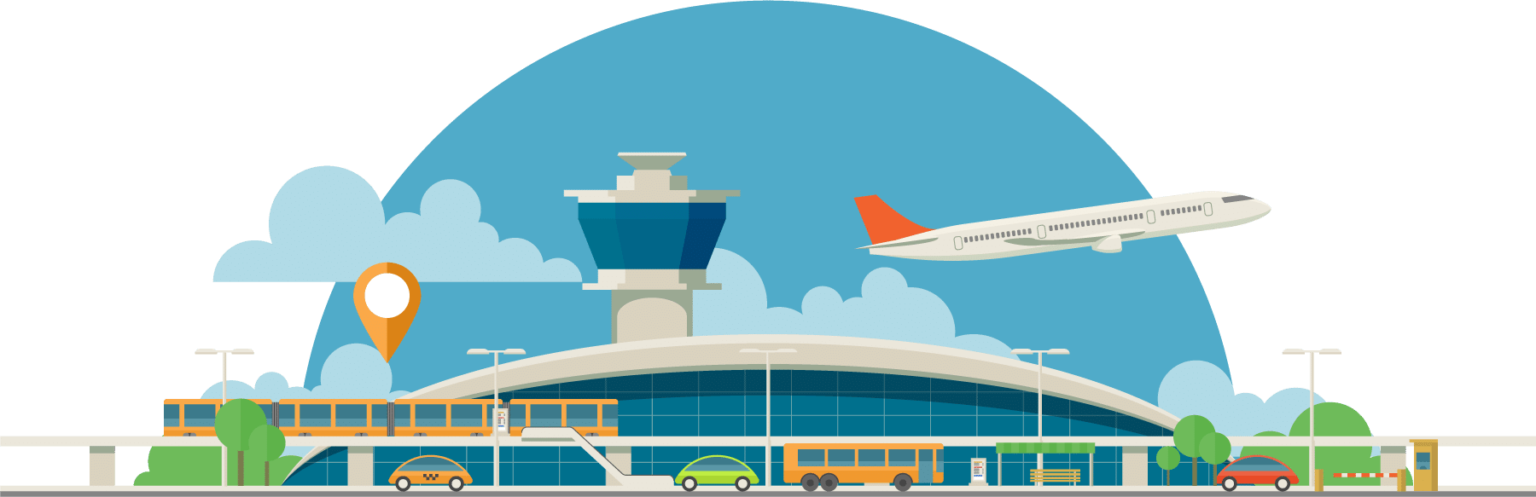

In [1]:
# # установка всех библиотек, необходимых для выполнения ДЗ

!pip install catboost
!pip install mlxtend --upgrade
!pip install optuna
!pip install lime
!pip install shap
!pip install missingno
!pip install psycopg2-binary


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# !pip install xgboost
# !brew install cmake libomp
!pip install lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno

import psycopg2
import psycopg2.extras

from mlxtend.plotting import plot_decision_regions
from mlxtend.evaluate import bias_variance_decomp
from graphviz import Source
from sklearn.tree import export_graphviz
from IPython.display import SVG

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.isotonic import IsotonicRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector, RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

import shap
import lime
import lime.lime_tabular

import optuna

import pickle

np.random.seed(42)

# **Часть 1: Получение данных, обработка и EDA (2.75 балла)**

В этой части вам необходимо:
- Загрузить данные из БД и предобработать их (1.75 бала)
- Провести разведочный анализ данных (1. балл)

## **1. 1. Загрузка и предобработка данных (1.75 балла)**

In [ ]:
# !brew install wget

In [3]:
!mkdir -p ~/.postgresql && \
wget "https://storage.yandexcloud.net/cloud-certs/CA.pem" \
    --output-document ~/.postgresql/root.crt && \
chmod 0600 ~/.postgresql/root.crt

--2026-02-19 23:31:56--  https://storage.yandexcloud.net/cloud-certs/CA.pem
Распознаётся storage.yandexcloud.net (storage.yandexcloud.net)… 213.180.193.243
Подключение к storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 3579 (3,5K) [application/x-x509-ca-cert]
Сохранение в: «/Users/dimko/.postgresql/root.crt»

/Users/dimko/.postg 100%[===================>]   3,50K  --.-KB/s    за 0s      

2026-02-19 23:31:56 (1,11 GB/s) - «/Users/dimko/.postgresql/root.crt» сохранён [3579/3579]



### **Задание 1. Получение данных (0.5 балла)**

- Подключитесь к БД при помощи `psycopg2.connect()`
- Напишите SQL-запрос, объединяющий 3 нужные таблицы в одну
- Результат запроса поместите в `pd.DataFrame`. Индексом получившегося датафрейма сделайте столбец 'id'.

Список столбцов таблиц добудьте самостоятельно.


**Примечание:**
 Не забудьте закрыть соединение. Или открывайте соединение, используя менеджер контекста `with as`, который закроет его автоматически

##### **Параметры соединения:**
```
host=rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net
port=6432
sslmode=verify-full
dbname=db_flights
user=mlhs_student
password=mlhs_student
target_session_attrs=read-write```
```

##### **Схема БД**

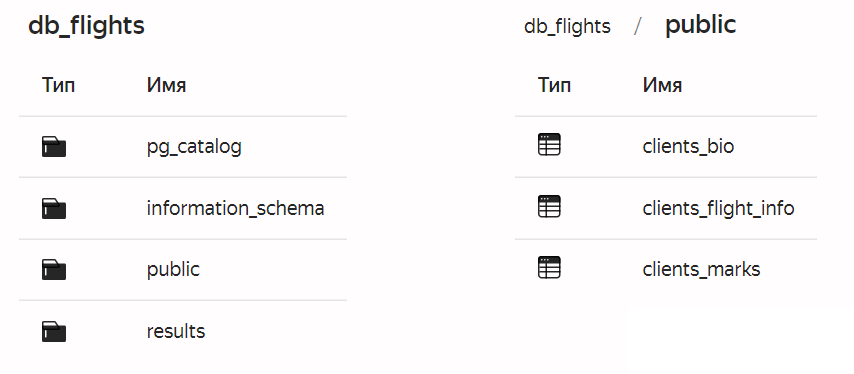



In [4]:
import psycopg2
import pandas as pd

In [5]:
conn_params = {
    'host': 'rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net',
    'port': 6432,
    'sslmode': 'verify-full',
    'dbname': 'db_flights',
    'user': 'mlhs_student',
    'password': 'mlhs_student',
    'target_session_attrs': 'read-write'
}

In [6]:
with psycopg2.connect(**conn_params) as conn:
    # SQL-запрос для объединения 3 таблиц из схемы public
    query = """
    SELECT 
        cb.id,
        cb.gender,
        cb.age,
        cfi."Customer Type",
        cfi."Type of Travel",
        cfi.class,
        cfi."Flight Distance",
        cfi."Departure Delay in Minutes",
        cfi."Arrival Delay in Minutes",
        cm.*
    FROM public.clients_bio cb
    JOIN public.clients_flight_info cfi ON cb.id = cfi.id
    JOIN public.clients_marks cm ON cb.id = cm.id
    ORDER BY cb.id
    """
    
    df = pd.read_sql_query(query, conn)
    
    # Удаляем дублирующиеся столбцы
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Устанавливаем id как индекс
    df.set_index('id', inplace=True)

print(f"Размер датафрейма: {df.shape}")
print(f"Первые строки:")
print(df.head())
print(f"Информация о датафрейме:")
print(df.info())

/var/folders/qw/wvqy2frs1tv5_tlkg6kbt7vc0000gn/T/ipykernel_72975/2856504649.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


Размер датафрейма: (129549, 23)
Первые строки:
    gender   age      Customer Type   Type of Travel     class  \
id                                                               
1     Male  48.0  disloyal Customer  Business travel  Business   
2   Female  35.0     Loyal Customer  Business travel  Business   
3     Male  41.0     Loyal Customer  Business travel  Business   
4     Male  50.0     Loyal Customer  Business travel  Business   
5   Female  49.0     Loyal Customer  Business travel  Business   

   Flight Distance Departure Delay in Minutes Arrival Delay in Minutes  \
id                                                                       
1            821.0                        2.0                      5.0   
2            821.0                       26.0                     39.0   
3            853.0                        0.0                      0.0   
4           1905.0                        0.0                      0.0   
5           3470.0                        0.0 

In [7]:
assert df.shape == (129_549, 23)

### **Задание 2 (0.25 балла)**

- Преобразуйте числовые столбцы в `float`. Проверьте, есть ли в датафрейме пропуски и выбросы (в том числе в категориальных признаках)</font>.

In [8]:
df.columns

Index(['gender', 'age', 'Customer Type', 'Type of Travel', 'class',
       'Flight Distance', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'cleanliness', 'satisfaction'],
      dtype='object')

In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 129549 entries, 1 to 129880
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   gender                             129549 non-null  object
 1   age                                129549 non-null  object
 2   Customer Type                      129549 non-null  object
 3   Type of Travel                     129549 non-null  object
 4   class                              129549 non-null  object
 5   Flight Distance                    129549 non-null  object
 6   Departure Delay in Minutes         129549 non-null  object
 7   Arrival Delay in Minutes           129549 non-null  object
 8   Inflight wifi service              129549 non-null  object
 9   Departure/Arrival time convenient  129549 non-null  object
 10  Ease of Online booking             129549 non-null  object
 11  Gate location                      129549 non-null  objec

None

In [10]:
numeric_cols_int = df.select_dtypes(include=['int64', 'int32']).columns
df[numeric_cols_int] = df[numeric_cols_int].astype('float64')

for col in df.select_dtypes(include=['object']).columns:
    try:
        df[col] = pd.to_numeric(df[col], errors='ignore')
        if df[col].dtype == 'object':
            test_series = pd.to_numeric(df[col], errors='coerce')
            if test_series.notna().sum() > 0:
                df[col] = test_series
    except:
        print("failed")
        pass

/var/folders/qw/wvqy2frs1tv5_tlkg6kbt7vc0000gn/T/ipykernel_72975/1173843324.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [11]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_counts,
    'Процент пропусков': missing_percent
})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False)

In [12]:
if len(missing_df) > 0:
    print(missing_df)
else:
    print("Пропусков не обнаружено")
    
print(f"Всего пропусков в датафрейме: {df.isnull().sum().sum()}")

                                   Количество пропусков  Процент пропусков
Arrival Delay in Minutes                            507           0.391358
age                                                 315           0.243151
Departure Delay in Minutes                          107           0.082594
Flight Distance                                      94           0.072559
Inflight service                                     63           0.048630
Food and drink                                       50           0.038595
Departure/Arrival time convenient                    49           0.037824
Baggage handling                                     48           0.037052
Seat comfort                                         47           0.036280
Leg room service                                     46           0.035508
Online boarding                                      46           0.035508
Inflight entertainment                               45           0.034736
On-board service         

Проверка числовых признаков (смотрим выбросы)

In [13]:
numeric_cols = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
outliers_info = []
for col in numeric_cols:
    if df[col].notna().sum() > 0:
        q996 = df[col].quantile(0.996)
        outliers_count = (df[col] > q996).sum()
        if outliers_count > 0:
            outliers_info.append({
                'Столбец': col,
                'Квантиль 0.996': q996,
                'Количество выбросов': outliers_count,
                'Максимальное значение': df[col].max()
            })
if outliers_info:
    outliers_df = pd.DataFrame(outliers_info)
    print(outliers_df)
else:
    print("Выбросов не обнаружено")

                              Столбец  Квантиль 0.996  Количество выбросов  \
0                                 age          80.000                  483   
1                     Flight Distance        3980.184                  518   
2          Departure Delay in Minutes         264.000                  512   
3            Arrival Delay in Minutes         265.000                  512   
4               Inflight wifi service           5.000                   34   
5   Departure/Arrival time convenient           5.000                   39   
6              Ease of Online booking           5.000                   30   
7                       Gate location           5.000                   43   
8                      Food and drink           5.000                   32   
9                     Online boarding           5.000                   34   
10                       Seat comfort           5.000                   43   
11             Inflight entertainment           5.000           

Проверка категориальных признаков

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_count = df[col].nunique()
    value_counts = df[col].value_counts()
    print(f"{col}: {unique_count} уникальных значений")
    print(value_counts.head())
    if df[col].dtype == 'object':
        value_lengths = df[col].astype(str).str.len()
        max_length = value_lengths.max()
        if max_length > 50:
            print(f"Предупреждение: есть очень длинные значения (макс. длина: {max_length})")

gender: 2 уникальных значений
gender
Female    65726
Male      63823
Name: count, dtype: int64
Customer Type: 3 уникальных значений
Customer Type
Loyal Customer       105763
disloyal Customer     23709
nan                      77
Name: count, dtype: int64
Type of Travel: 3 уникальных значений
Type of Travel
Business travel    89405
Personal Travel    40043
nan                  101
Name: count, dtype: int64
class: 4 уникальных значений
class
Business    61939
Eco         58115
Eco Plus     9379
nan           116
Name: count, dtype: int64
satisfaction: 3 уникальных значений
satisfaction
neutral or dissatisfied    58732
satisfied                  44912
-                          25905
Name: count, dtype: int64


### **Задание 3 (0.5 балла)**

Воспользуйтесь модулем `missingno` для визуализации пропусков в датафрейме. Постройте:
-  `matrix` пропущенных значений;
- столбчатую диаграмму в **логарифмированной** шкале (так как пропусков немного, по обычной не будет видно, в каких столбцах их больше)

In [15]:
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np

/var/folders/qw/wvqy2frs1tv5_tlkg6kbt7vc0000gn/T/ipykernel_72975/4136892724.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1500x800 with 0 Axes>

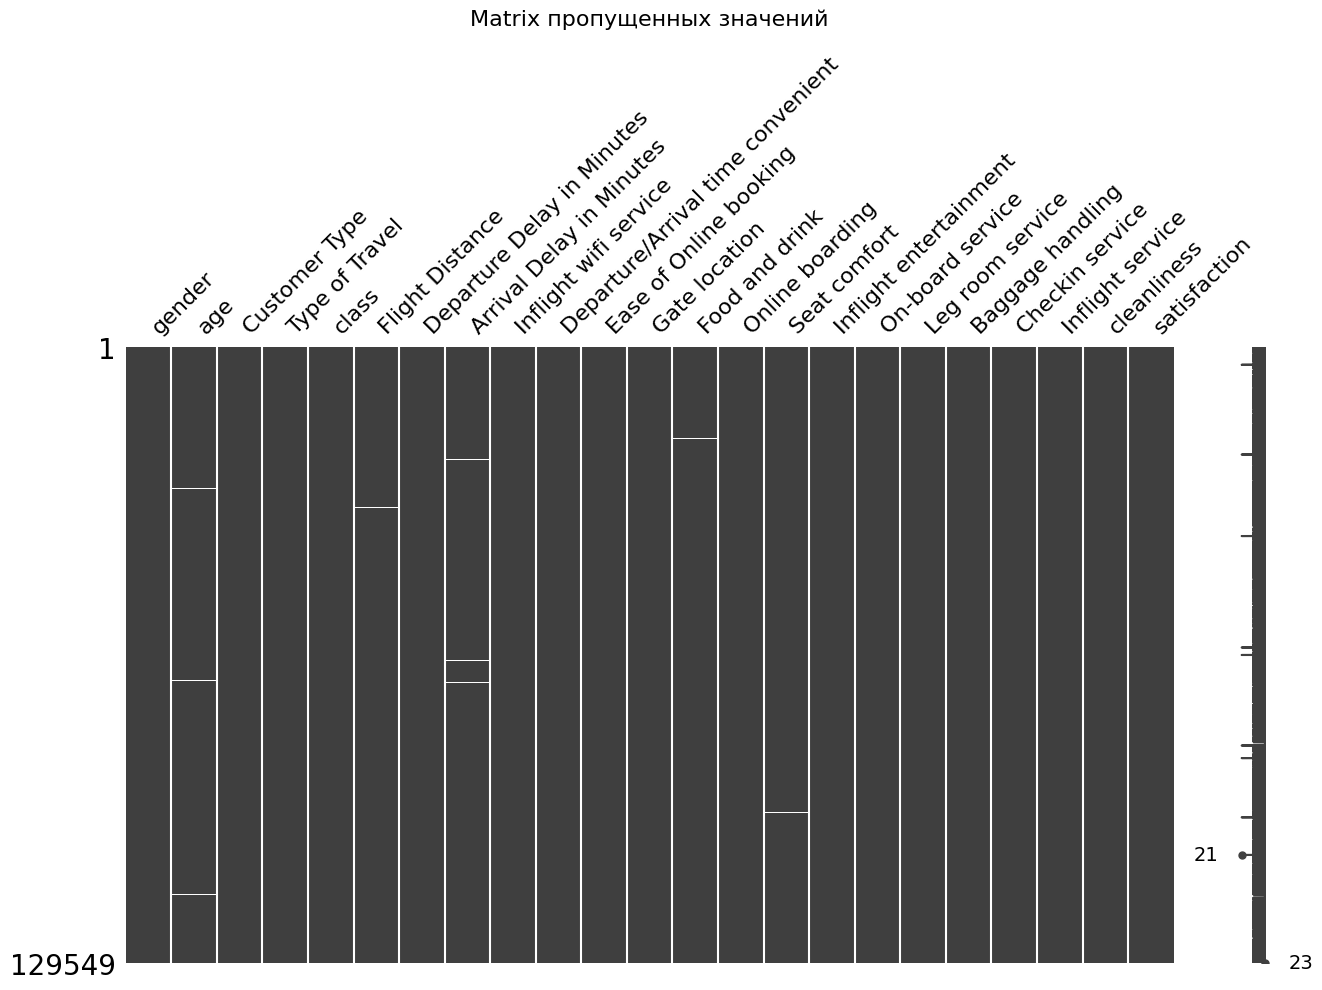

In [16]:
plt.figure(figsize=(15, 8))
msno.matrix(df, figsize=(15, 8))
plt.title('Matrix пропущенных значений', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

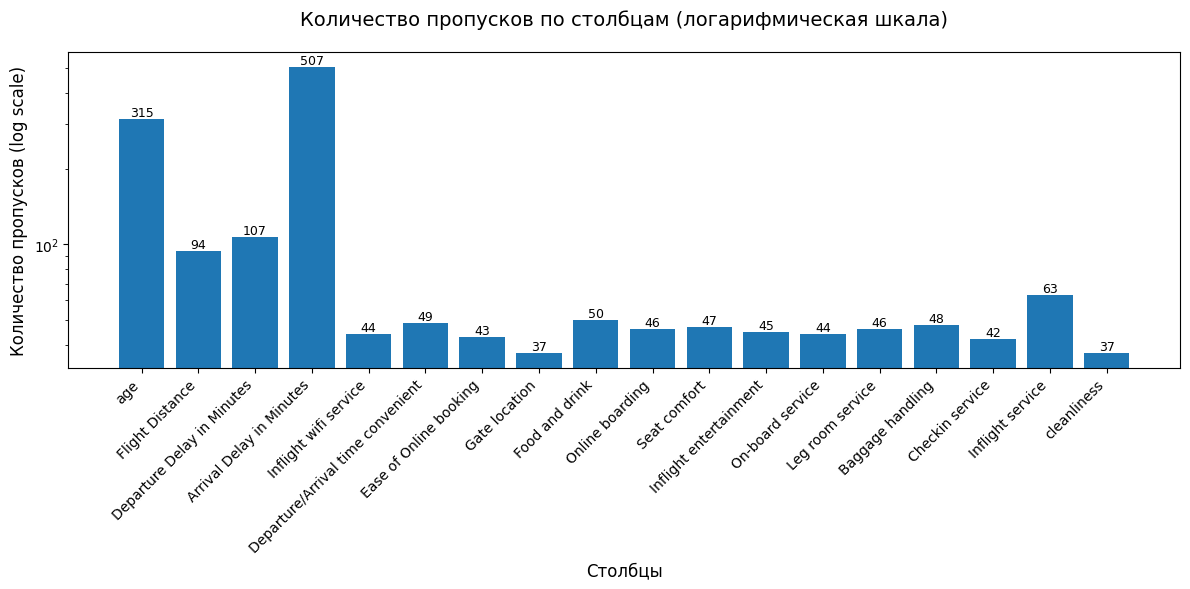

Столбцы с пропусками:
  age: 315 пропусков (0.24%)
  Flight Distance: 94 пропусков (0.07%)
  Departure Delay in Minutes: 107 пропусков (0.08%)
  Arrival Delay in Minutes: 507 пропусков (0.39%)
  Inflight wifi service: 44 пропусков (0.03%)
  Departure/Arrival time convenient: 49 пропусков (0.04%)
  Ease of Online booking: 43 пропусков (0.03%)
  Gate location: 37 пропусков (0.03%)
  Food and drink: 50 пропусков (0.04%)
  Online boarding: 46 пропусков (0.04%)
  Seat comfort: 47 пропусков (0.04%)
  Inflight entertainment: 45 пропусков (0.03%)
  On-board service: 44 пропусков (0.03%)
  Leg room service: 46 пропусков (0.04%)
  Baggage handling: 48 пропусков (0.04%)
  Checkin service: 42 пропусков (0.03%)
  Inflight service: 63 пропусков (0.05%)
  cleanliness: 37 пропусков (0.03%)


In [17]:
if len(missing_counts) > 0:
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(missing_counts)), missing_counts.values)
    plt.yscale('log')
    plt.xlabel('Столбцы', fontsize=12)
    plt.ylabel('Количество пропусков (log scale)', fontsize=12)
    plt.title('Количество пропусков по столбцам (логарифмическая шкала)', fontsize=14, pad=20)
    plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45, ha='right')
    for i, (idx, val) in enumerate(missing_counts.items()):
        plt.text(i, val, str(val), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"Столбцы с пропусками:")
    for col, count in missing_counts.items():
        print(f"  {col}: {count} пропусков ({count/len(df)*100:.2f}%)")
else:
    print("Пропусков не обнаружено")

Разобьем датасет на тренировочную и тестовую части. Тестовую часть отложим надолго -- до самого конца этого ноутбука.

In [18]:
df_train = df[df.satisfaction != '-']
df_train

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
1,Male,48.0,disloyal Customer,Business travel,Business,821.0,2.0,5.0,3.0,3.0,...,3.0,5.0,5.0,3.0,2.0,5.0,4.0,5.0,5.0,neutral or dissatisfied
2,Female,35.0,Loyal Customer,Business travel,Business,821.0,26.0,39.0,2.0,2.0,...,5.0,4.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,satisfied
3,Male,41.0,Loyal Customer,Business travel,Business,853.0,0.0,0.0,4.0,4.0,...,5.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0,5.0,satisfied
4,Male,50.0,Loyal Customer,Business travel,Business,1905.0,0.0,0.0,2.0,2.0,...,4.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,4.0,satisfied
5,Female,49.0,Loyal Customer,Business travel,Business,3470.0,0.0,1.0,3.0,3.0,...,5.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,5.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129874,Female,28.0,Loyal Customer,Personal Travel,Eco Plus,337.0,0.0,0.0,4.0,2.0,...,4.0,3.0,3.0,1.0,5.0,3.0,4.0,4.0,3.0,neutral or dissatisfied
129875,Female,55.0,Loyal Customer,Personal Travel,Eco Plus,308.0,0.0,0.0,3.0,4.0,...,4.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,neutral or dissatisfied
129878,Male,42.0,Loyal Customer,Personal Travel,Eco Plus,337.0,6.0,14.0,2.0,5.0,...,2.0,3.0,3.0,3.0,4.0,5.0,4.0,4.0,3.0,neutral or dissatisfied


In [19]:
assert df_train.shape == (103_644, 23)

In [20]:
df_test = df[df.satisfaction == '-'].drop('satisfaction', axis=1)
df_test

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
id,,,,,,,,,,,,,,,,,,,,,
17,Female,48.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,3.0,...,1.0,5.0,1.0,5.0,5.0,2.0,5.0,5.0,5.0,2.0
20,Female,42.0,Loyal Customer,Personal Travel,Eco,821.0,4.0,0.0,3.0,3.0,...,1.0,3.0,4.0,1.0,1.0,3.0,1.0,3.0,1.0,3.0
35,Male,39.0,Loyal Customer,Business travel,Business,1672.0,23.0,17.0,2.0,2.0,...,5.0,4.0,5.0,3.0,3.0,4.0,5.0,5.0,3.0,5.0
44,Male,51.0,Loyal Customer,Business travel,Business,2077.0,0.0,1.0,4.0,1.0,...,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0
49,Male,20.0,disloyal Customer,Business travel,Eco,108.0,0.0,29.0,4.0,5.0,...,5.0,4.0,3.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129847,Female,16.0,Loyal Customer,Personal Travel,Eco,337.0,0.0,0.0,0.0,4.0,...,3.0,0.0,3.0,3.0,5.0,2.0,4.0,4.0,5.0,3.0
129868,Male,47.0,Loyal Customer,Business travel,Eco Plus,447.0,0.0,0.0,3.0,4.0,...,4.0,3.0,4.0,4.0,2.0,5.0,3.0,1.0,4.0,4.0
129872,Female,32.0,Loyal Customer,Business travel,Eco Plus,337.0,0.0,1.0,4.0,2.0,...,4.0,4.0,4.0,4.0,5.0,1.0,3.0,5.0,1.0,4.0


In [21]:
assert df_test.shape == (25_905, 22)

Разбиваем данные на трейн и валидацию. Не меняйте сид

In [22]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop('satisfaction', axis=1), df_train.satisfaction, test_size=0.3, random_state=42)

In [23]:
assert X_train.shape == (72_550, 22)
assert X_val.shape == (31_094, 22)

### **Задание 4. (0.15 балла)**

Заполните пропуски в данных наиболее часто встречающимся значением.
Помните про правильность заполнения.

**Примечание:** Мы также могли восстановать пропуски `KNNImputer`'ом или `IterativeImputer`'ом. Как правило, такое заполнение точнее и лучше сохраняет структуру распределений. Но для признаков в нашей задаче Imputer'ы, реализованные библиотечно не подошли бы. Они возвращали бы вещественные значения, а в нашей задаче все признаки целые.

In [24]:
from sklearn.impute import SimpleImputer

In [25]:
numeric_cols = X_train.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy='most_frequent')
    X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])
    X_val[numeric_cols] = numeric_imputer.transform(X_val[numeric_cols])

In [26]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_cols] = categorical_imputer.fit_transform(X_train[categorical_cols])
    X_val[categorical_cols] = categorical_imputer.transform(X_val[categorical_cols])

In [27]:
print("Проверка пропусков после заполнения:")
print(f"Пропуски в X_train: {X_train.isnull().sum().sum()}")
print(f"Пропуски в X_val: {X_val.isnull().sum().sum()}")

Проверка пропусков после заполнения:
Пропуски в X_train: 0
Пропуски в X_val: 0


In [28]:
if X_train.isnull().sum().sum() > 0:
    print("\nСтолбцы с пропусками в X_train:")
    print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
if X_val.isnull().sum().sum() > 0:
    print("\nСтолбцы с пропусками в X_val:")
    print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

### **Задание 5. (0.1 балла)**

- Выведите основные статистики по числовым и категориальным столбцам таблицы
- Сделайте **текстовый** вывод о распределениях значений признаков

Статистика по числовым столбцам

In [29]:
numeric_cols = X_train.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
if len(numeric_cols) > 0:
    print(X_train[numeric_cols].describe())
    print(f"Количество числовых признаков: {len(numeric_cols)}")
else:
    print("Числовых столбцов не найдено")

                age  Flight Distance  Departure Delay in Minutes  \
count  72550.000000     72550.000000                72550.000000   
mean      40.083666      1338.222261                   15.642591   
std       20.355546      4838.640464                   67.829985   
min        0.000000         0.000000                    0.000000   
25%       27.000000       413.000000                    0.000000   
50%       40.000000       842.000000                    0.000000   
75%       51.000000      1744.000000                   12.000000   
max      612.000000    328510.000000                 9282.000000   

       Arrival Delay in Minutes  Inflight wifi service  \
count              72550.000000           72550.000000   
mean                  16.381116               2.735603   
std                  100.546087               1.366913   
min                    0.000000               0.000000   
25%                    0.000000               2.000000   
50%                    0.000000        

Статистика по категориальным столбцам

In [30]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    value_counts = X_train[col].value_counts()
    print(value_counts)
    print(f"Количество уникальных значений: {X_train[col].nunique()}")
    print(f"Процент наиболее частого значения: {value_counts.iloc[0] / len(X_train) * 100:.2f}%")



gender:
gender
Female    36738
Male      35812
Name: count, dtype: int64
Количество уникальных значений: 2
Процент наиболее частого значения: 50.64%

Customer Type:
Customer Type
Loyal Customer       59314
disloyal Customer    13186
nan                     50
Name: count, dtype: int64
Количество уникальных значений: 3
Процент наиболее частого значения: 81.76%

Type of Travel:
Type of Travel
Business travel    49992
Personal Travel    22504
nan                   54
Name: count, dtype: int64
Количество уникальных значений: 3
Процент наиболее частого значения: 68.91%

class:
class
Business    34574
Eco         32668
Eco Plus     5243
nan            65
Name: count, dtype: int64
Количество уникальных значений: 4
Процент наиболее частого значения: 47.66%


**Выводы о распределениях значений признаков:**

**Числовые признаки:**
- **age (возраст)**: Распределение близко к нормальному с небольшим смещением вправо. Средний возраст около 40-45 лет. Есть выбросы (максимальное значение 621, что явно аномалия).
- **Flight Distance (расстояние полета)**: Распределение сильно правостороннее (положительная асимметрия). Большинство полетов на короткие и средние расстояния, но есть длинные перелеты.
- **Departure Delay in Minutes / Arrival Delay in Minutes**: Сильно правостороннее распределение с большим количеством нулевых значений (большинство рейсов без задержек). Есть экстремальные выбросы (задержки до 22227 минут).
- **Порядковые признаки (рейтинги сервисов)**: Все признаки имеют распределение от 0 до 5, большинство значений сосредоточены в диапазоне 2-4. Распределения похожи между собой, что указывает на коррелированность оценок различных сервисов.

**Категориальные признаки:**
- **gender**: Равномерное распределение между Male и Female (~50/50).
- **Customer Type**: Сильный дисбаланс - большинство клиентов "Loyal Customer" (~81.76%), только ~18% "disloyal Customer".
- **Type of Travel**: Большинство клиентов путешествуют по бизнесу (~68.91%), меньше по личным причинам (~31%).
- **class**: Наиболее популярен Business класс (~47.66%), затем Eco (~45.7%), и значительно меньше Eco Plus (~7.3%).

**Целевая переменная (satisfaction):**
- Классы несбалансированы: ~56.6% "neutral or dissatisfied" и ~43.4% "satisfied". Это умеренный дисбаланс, который стоит учитывать при обучении модели.

### **Задание 6 (0.25 балла)**

- Удалите строки c выбросами в числовых столбцах (для трейна и валидации; тест оставьте без изменений).

**Примечание:** Выбросами считайте значения признака, строго превышающие 0.996-квантиль.

По определению, квантиль — значение, которое заданная случайная величина не превышает с фиксированной вероятностью. То есть, если мы смотрим на квантиль 0.996-квантиль, то значения после этого квантиля встречаются в 0.004% случаев. В среднем для всех признаков эти значения начинаются ~в этом квантиле.



In [31]:
numeric_cols = X_train.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns

print(f"Исходный размер X_train: {X_train.shape}")
print(f"Исходный размер X_val: {X_val.shape}")

Исходный размер X_train: (72550, 22)
Исходный размер X_val: (31094, 22)


In [32]:
outlier_mask_train = pd.Series([False] * len(X_train), index=X_train.index)
for col in numeric_cols:
    if X_train[col].notna().sum() > 0:
        q996 = X_train[col].quantile(0.996)
        col_outliers = (X_train[col] > q996)
        outlier_mask_train |= col_outliers
        if col_outliers.sum() > 0:
            print(f"{col}: {col_outliers.sum()} выбросов (квантиль 0.996 = {q996:.2f})")

age: 260 выбросов (квантиль 0.996 = 80.00)
Flight Distance: 291 выбросов (квантиль 0.996 = 3980.80)
Departure Delay in Minutes: 291 выбросов (квантиль 0.996 = 258.80)
Arrival Delay in Minutes: 286 выбросов (квантиль 0.996 = 262.00)
Inflight wifi service: 16 выбросов (квантиль 0.996 = 5.00)
Departure/Arrival time convenient: 20 выбросов (квантиль 0.996 = 5.00)
Ease of Online booking: 17 выбросов (квантиль 0.996 = 5.00)
Gate location: 18 выбросов (квантиль 0.996 = 5.00)
Food and drink: 14 выбросов (квантиль 0.996 = 5.00)
Online boarding: 26 выбросов (квантиль 0.996 = 5.00)
Seat comfort: 22 выбросов (квантиль 0.996 = 5.00)
Inflight entertainment: 16 выбросов (квантиль 0.996 = 5.00)
On-board service: 17 выбросов (квантиль 0.996 = 5.00)
Leg room service: 26 выбросов (квантиль 0.996 = 5.00)
Baggage handling: 17 выбросов (квантиль 0.996 = 5.00)
Checkin service: 25 выбросов (квантиль 0.996 = 5.00)
Inflight service: 27 выбросов (квантиль 0.996 = 5.00)
cleanliness: 15 выбросов (квантиль 0.996 = 

In [33]:
outlier_mask_val = pd.Series([False] * len(X_val), index=X_val.index)
for col in numeric_cols:
    if X_val[col].notna().sum() > 0:
        q996 = X_train[col].quantile(0.996)
        col_outliers = (X_val[col] > q996)
        outlier_mask_val |= col_outliers
        if col_outliers.sum() > 0:
            print(f"{col} (val): {col_outliers.sum()} выбросов (квантиль 0.996 = {q996:.2f})")

age (val): 111 выбросов (квантиль 0.996 = 80.00)
Flight Distance (val): 115 выбросов (квантиль 0.996 = 3980.80)
Departure Delay in Minutes (val): 149 выбросов (квантиль 0.996 = 258.80)
Arrival Delay in Minutes (val): 150 выбросов (квантиль 0.996 = 262.00)
Inflight wifi service (val): 10 выбросов (квантиль 0.996 = 5.00)
Departure/Arrival time convenient (val): 12 выбросов (квантиль 0.996 = 5.00)
Ease of Online booking (val): 6 выбросов (квантиль 0.996 = 5.00)
Gate location (val): 14 выбросов (квантиль 0.996 = 5.00)
Food and drink (val): 5 выбросов (квантиль 0.996 = 5.00)
Online boarding (val): 4 выбросов (квантиль 0.996 = 5.00)
Seat comfort (val): 7 выбросов (квантиль 0.996 = 5.00)
Inflight entertainment (val): 4 выбросов (квантиль 0.996 = 5.00)
On-board service (val): 6 выбросов (квантиль 0.996 = 5.00)
Leg room service (val): 10 выбросов (квантиль 0.996 = 5.00)
Baggage handling (val): 5 выбросов (квантиль 0.996 = 5.00)
Checkin service (val): 6 выбросов (квантиль 0.996 = 5.00)
Inflight 

In [34]:
rows_before_train = len(X_train)
rows_before_val = len(X_val)

X_train = X_train[~outlier_mask_train].copy()
y_train = y_train[~outlier_mask_train]
X_val = X_val[~outlier_mask_val].copy()
y_val = y_val[~outlier_mask_val]

rows_removed_train = rows_before_train - len(X_train)
rows_removed_val = rows_before_val - len(X_val)

In [35]:
print(f"Удалено строк из train: {rows_removed_train} ({rows_removed_train/rows_before_train*100:.2f}%)")
print(f"Удалено строк из val: {rows_removed_val} ({rows_removed_val/rows_before_val*100:.2f}%)")
print(f"Новый размер X_train: {X_train.shape}")
print(f"Новый размер X_val: {X_val.shape}")
print(f"Размер df_test: {df_test.shape}")

Удалено строк из train: 1181 (1.63%)
Удалено строк из val: 503 (1.62%)
Новый размер X_train: (71369, 22)
Новый размер X_val: (30591, 22)
Размер df_test: (25905, 22)


In [36]:
assert df_test.shape == (25_905, 22)

## **1. 2. EDA (1 балл)**

Создадим переменные с перечислениями столбцов разного типа

In [37]:
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_cols = list(set(df.select_dtypes(include='number').columns) - set(continuous_cols))
categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]

In [38]:
assert len(continuous_cols + ordinal_cols + categorical_cols) == 22

### **Задание 7. (0.3 балла)**

- Напишите процедуры для отрисовки графиков;
 * Для признаков, которые мы выделили как порядковые и для категориальных, отображайте только `countplot`
  * Для тех, что считаем континуальными, -- гистограмму распределения признака и ящик с усами (inline)

- Вызовите все 3 написанные процедуры для соответствующих колонок `X_train`. Отдельно визуализируйте распределение таргета в трейне. Всё должно красиво работать! :)

**Примечание 1:**

Помните про хороший тон визуализации — все графики и их оси обязательно должны быть подписаны, легенда на графике также необходима! За неё также могут быть сняты баллы.

**Примечание 2:**

Обязательно выделяйте таргет разными цветами. Мы же хотим в конечном итоге понять, чем удовлетворенные клиенты отличаются от недовольных.

In [39]:
def plot_ordinal(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n_cols = len(cols)
    if n_cols == 0:
        return
    
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, col in enumerate(cols):
        ax = axes[idx]
        sns.countplot(data=df, x=col, hue=y, ax=ax)
        ax.set_title(f'Распределение {col} по классам', fontsize=12, pad=10)
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Количество', fontsize=10)
        ax.legend(title='Satisfaction', labels=['Неудовлетворен', 'Удовлетворен'])
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

In [40]:
def plot_continuous(cols, df, y):
    """Draws kdeplots and boxplots in one row
    for all columns in 'cols' with informative title
    """
    n_cols = len(cols)
    if n_cols == 0:
        return
    
    fig, axes = plt.subplots(n_cols, 2, figsize=(16, 5 * n_cols))
    if n_cols == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(cols):
        ax1 = axes[idx, 0]
        for label in y.unique():
            sns.kdeplot(data=df[y == label], x=col, label=label, ax=ax1)
        ax1.set_title(f'Распределение {col}', fontsize=12, pad=10)
        ax1.set_xlabel(col, fontsize=10)
        ax1.set_ylabel('Плотность', fontsize=10)
        ax1.legend(title='Satisfaction')
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[idx, 1]
        sns.boxplot(data=df, x=y, y=col, ax=ax2)
        ax2.set_title(f'Ящик с усами для {col}', fontsize=12, pad=10)
        ax2.set_xlabel('Satisfaction', fontsize=10)
        ax2.set_ylabel(col, fontsize=10)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [41]:
def plot_categorical(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    n_cols = len(cols)
    if n_cols == 0:
        return
    
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, col in enumerate(cols):
        ax = axes[idx]
        sns.countplot(data=df, x=col, hue=y, ax=ax)
        ax.set_title(f'Распределение {col} по классам', fontsize=12, pad=10)
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Количество', fontsize=10)
        ax.legend(title='Satisfaction', labels=['Неудовлетворен', 'Удовлетворен'])
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

Отрисовка.

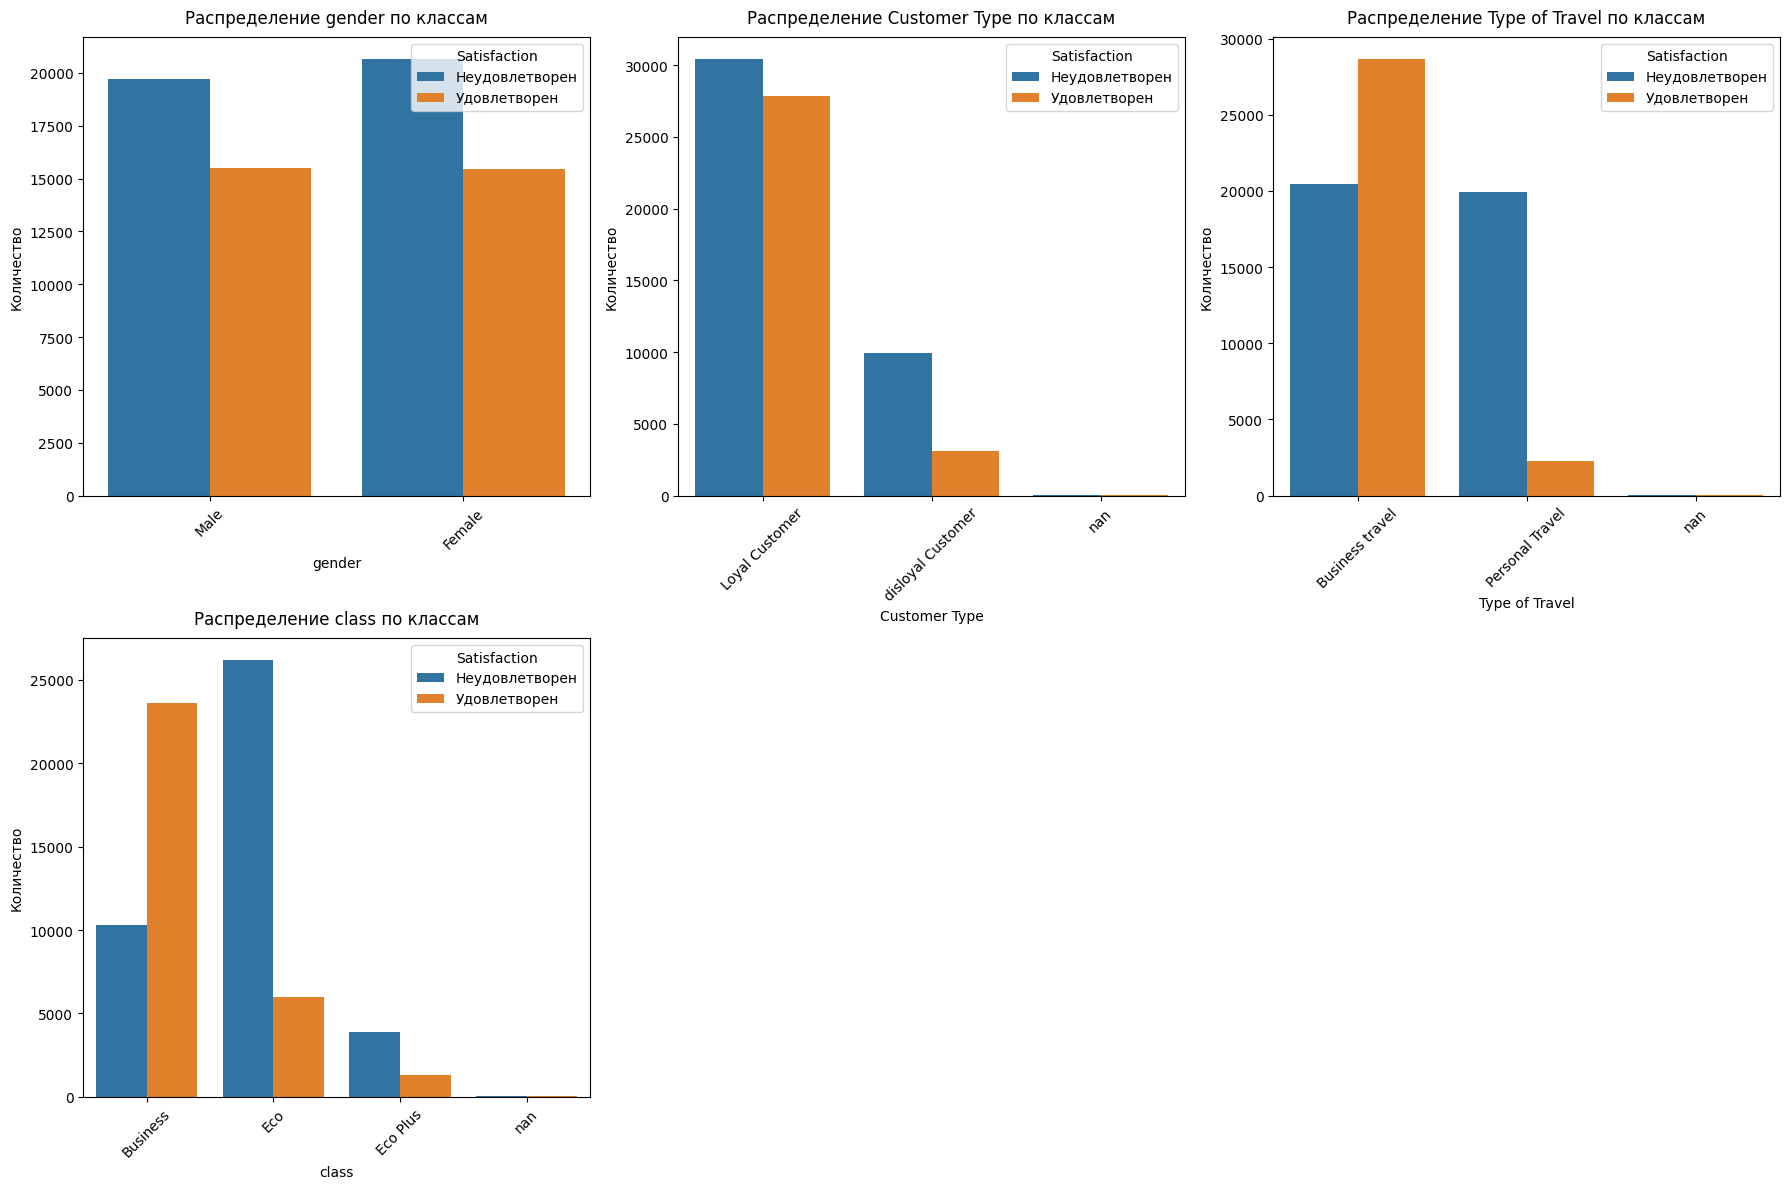

In [42]:
plot_categorical(categorical_cols, X_train, y_train)

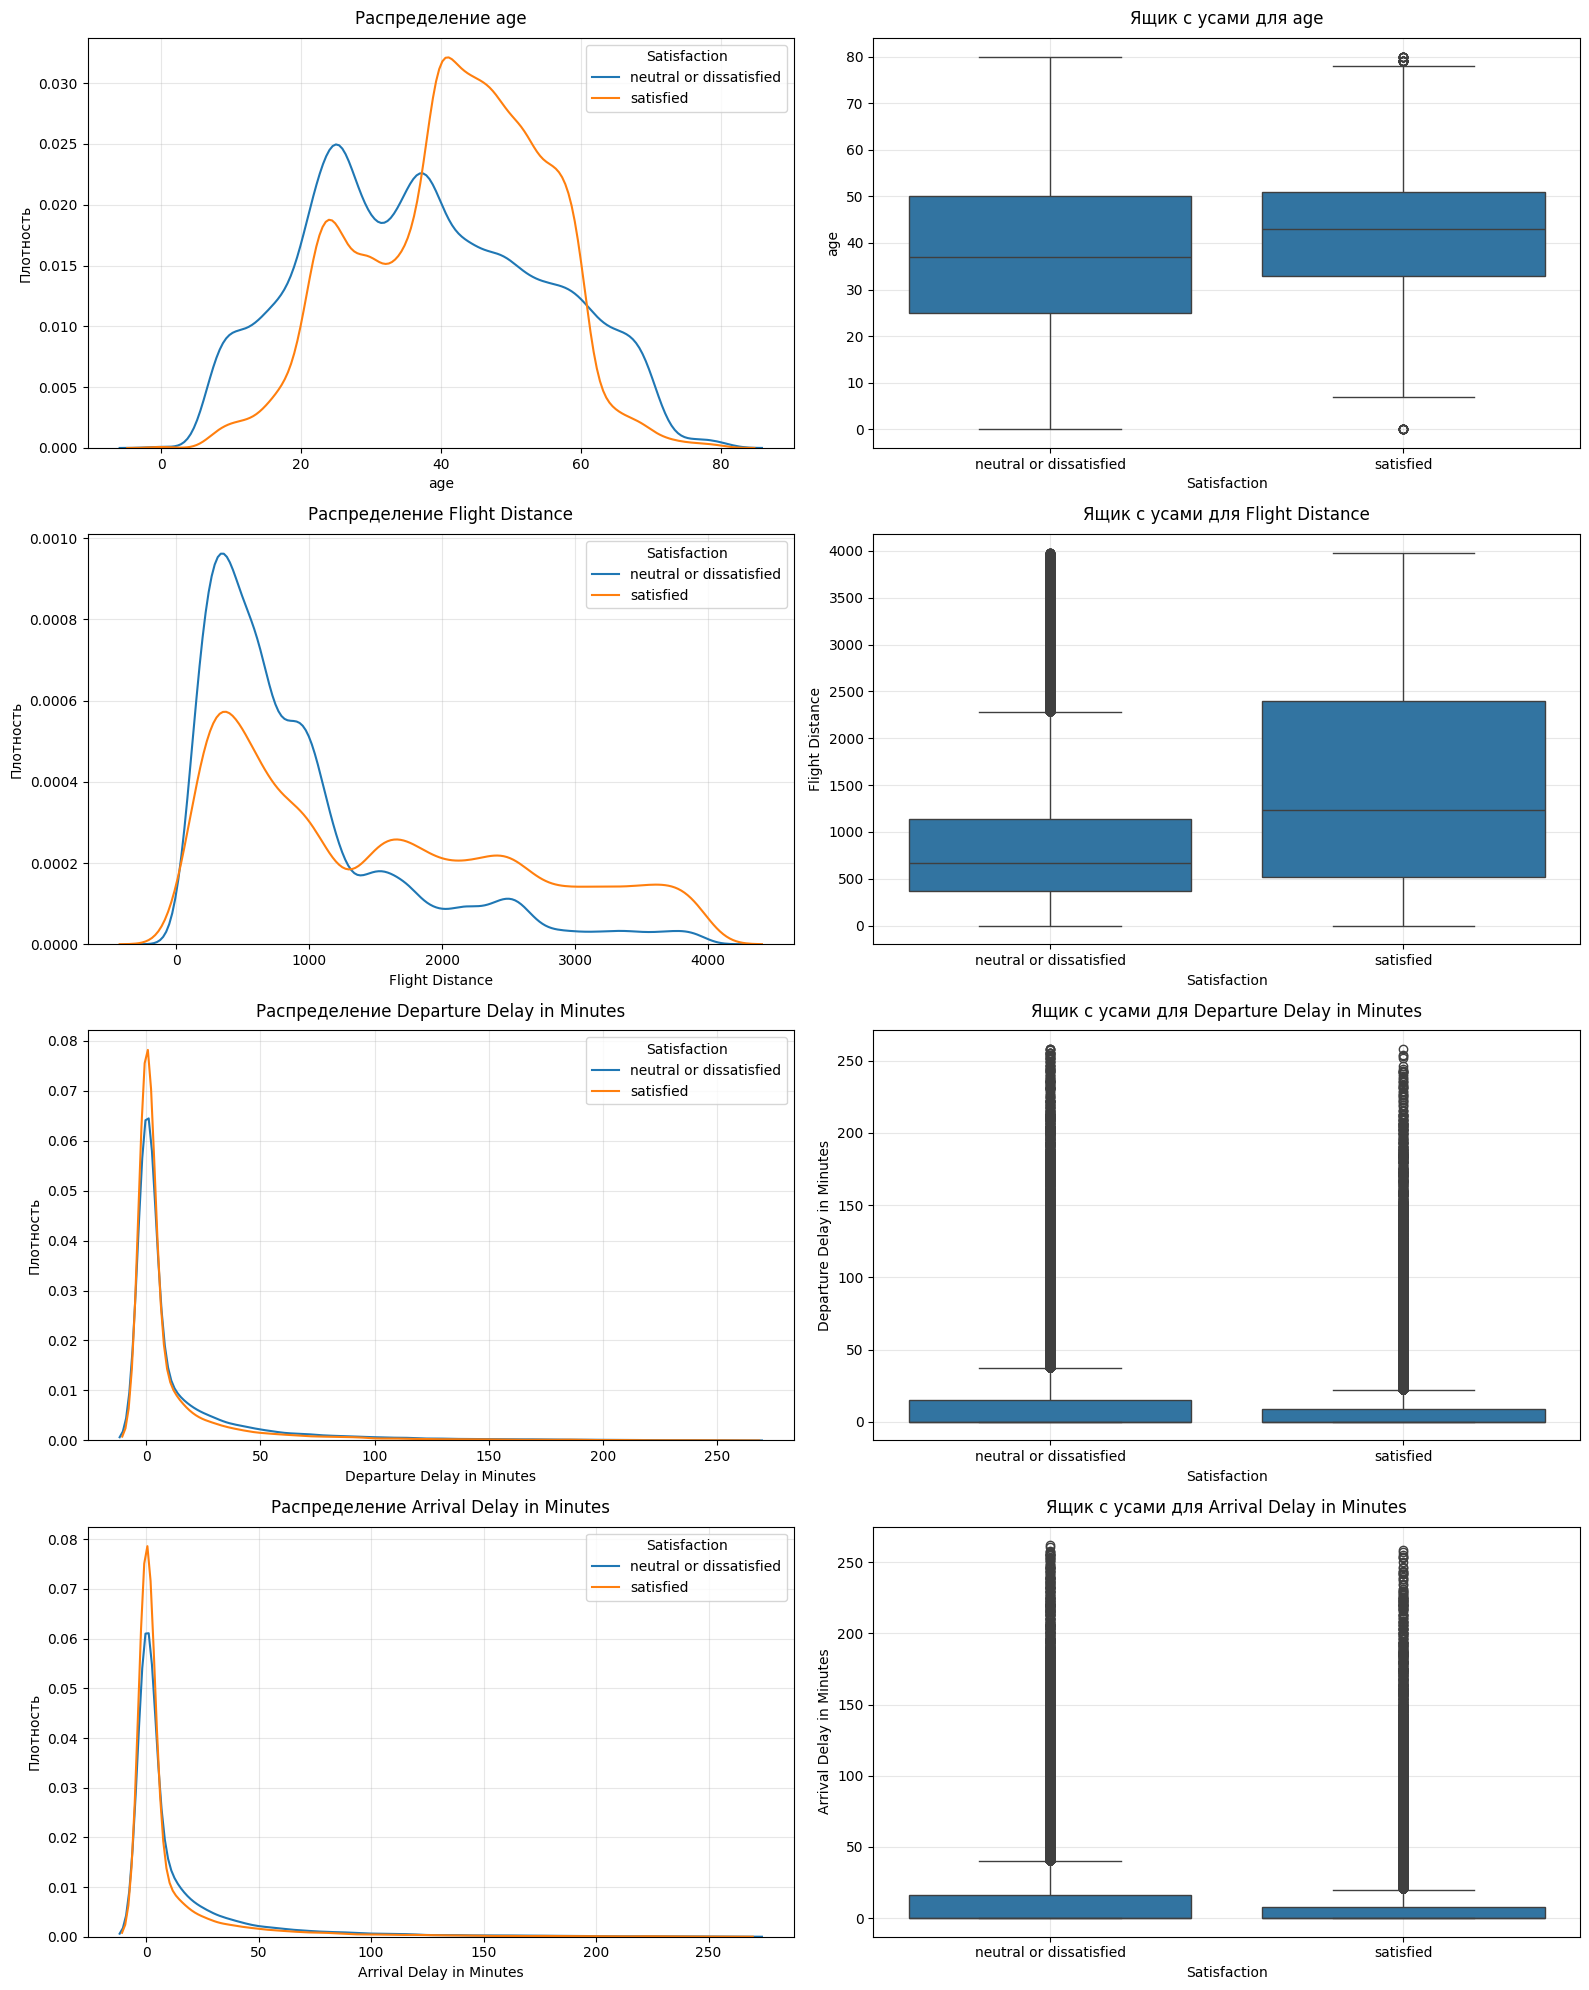

In [43]:
plot_continuous(continuous_cols, X_train, y_train)

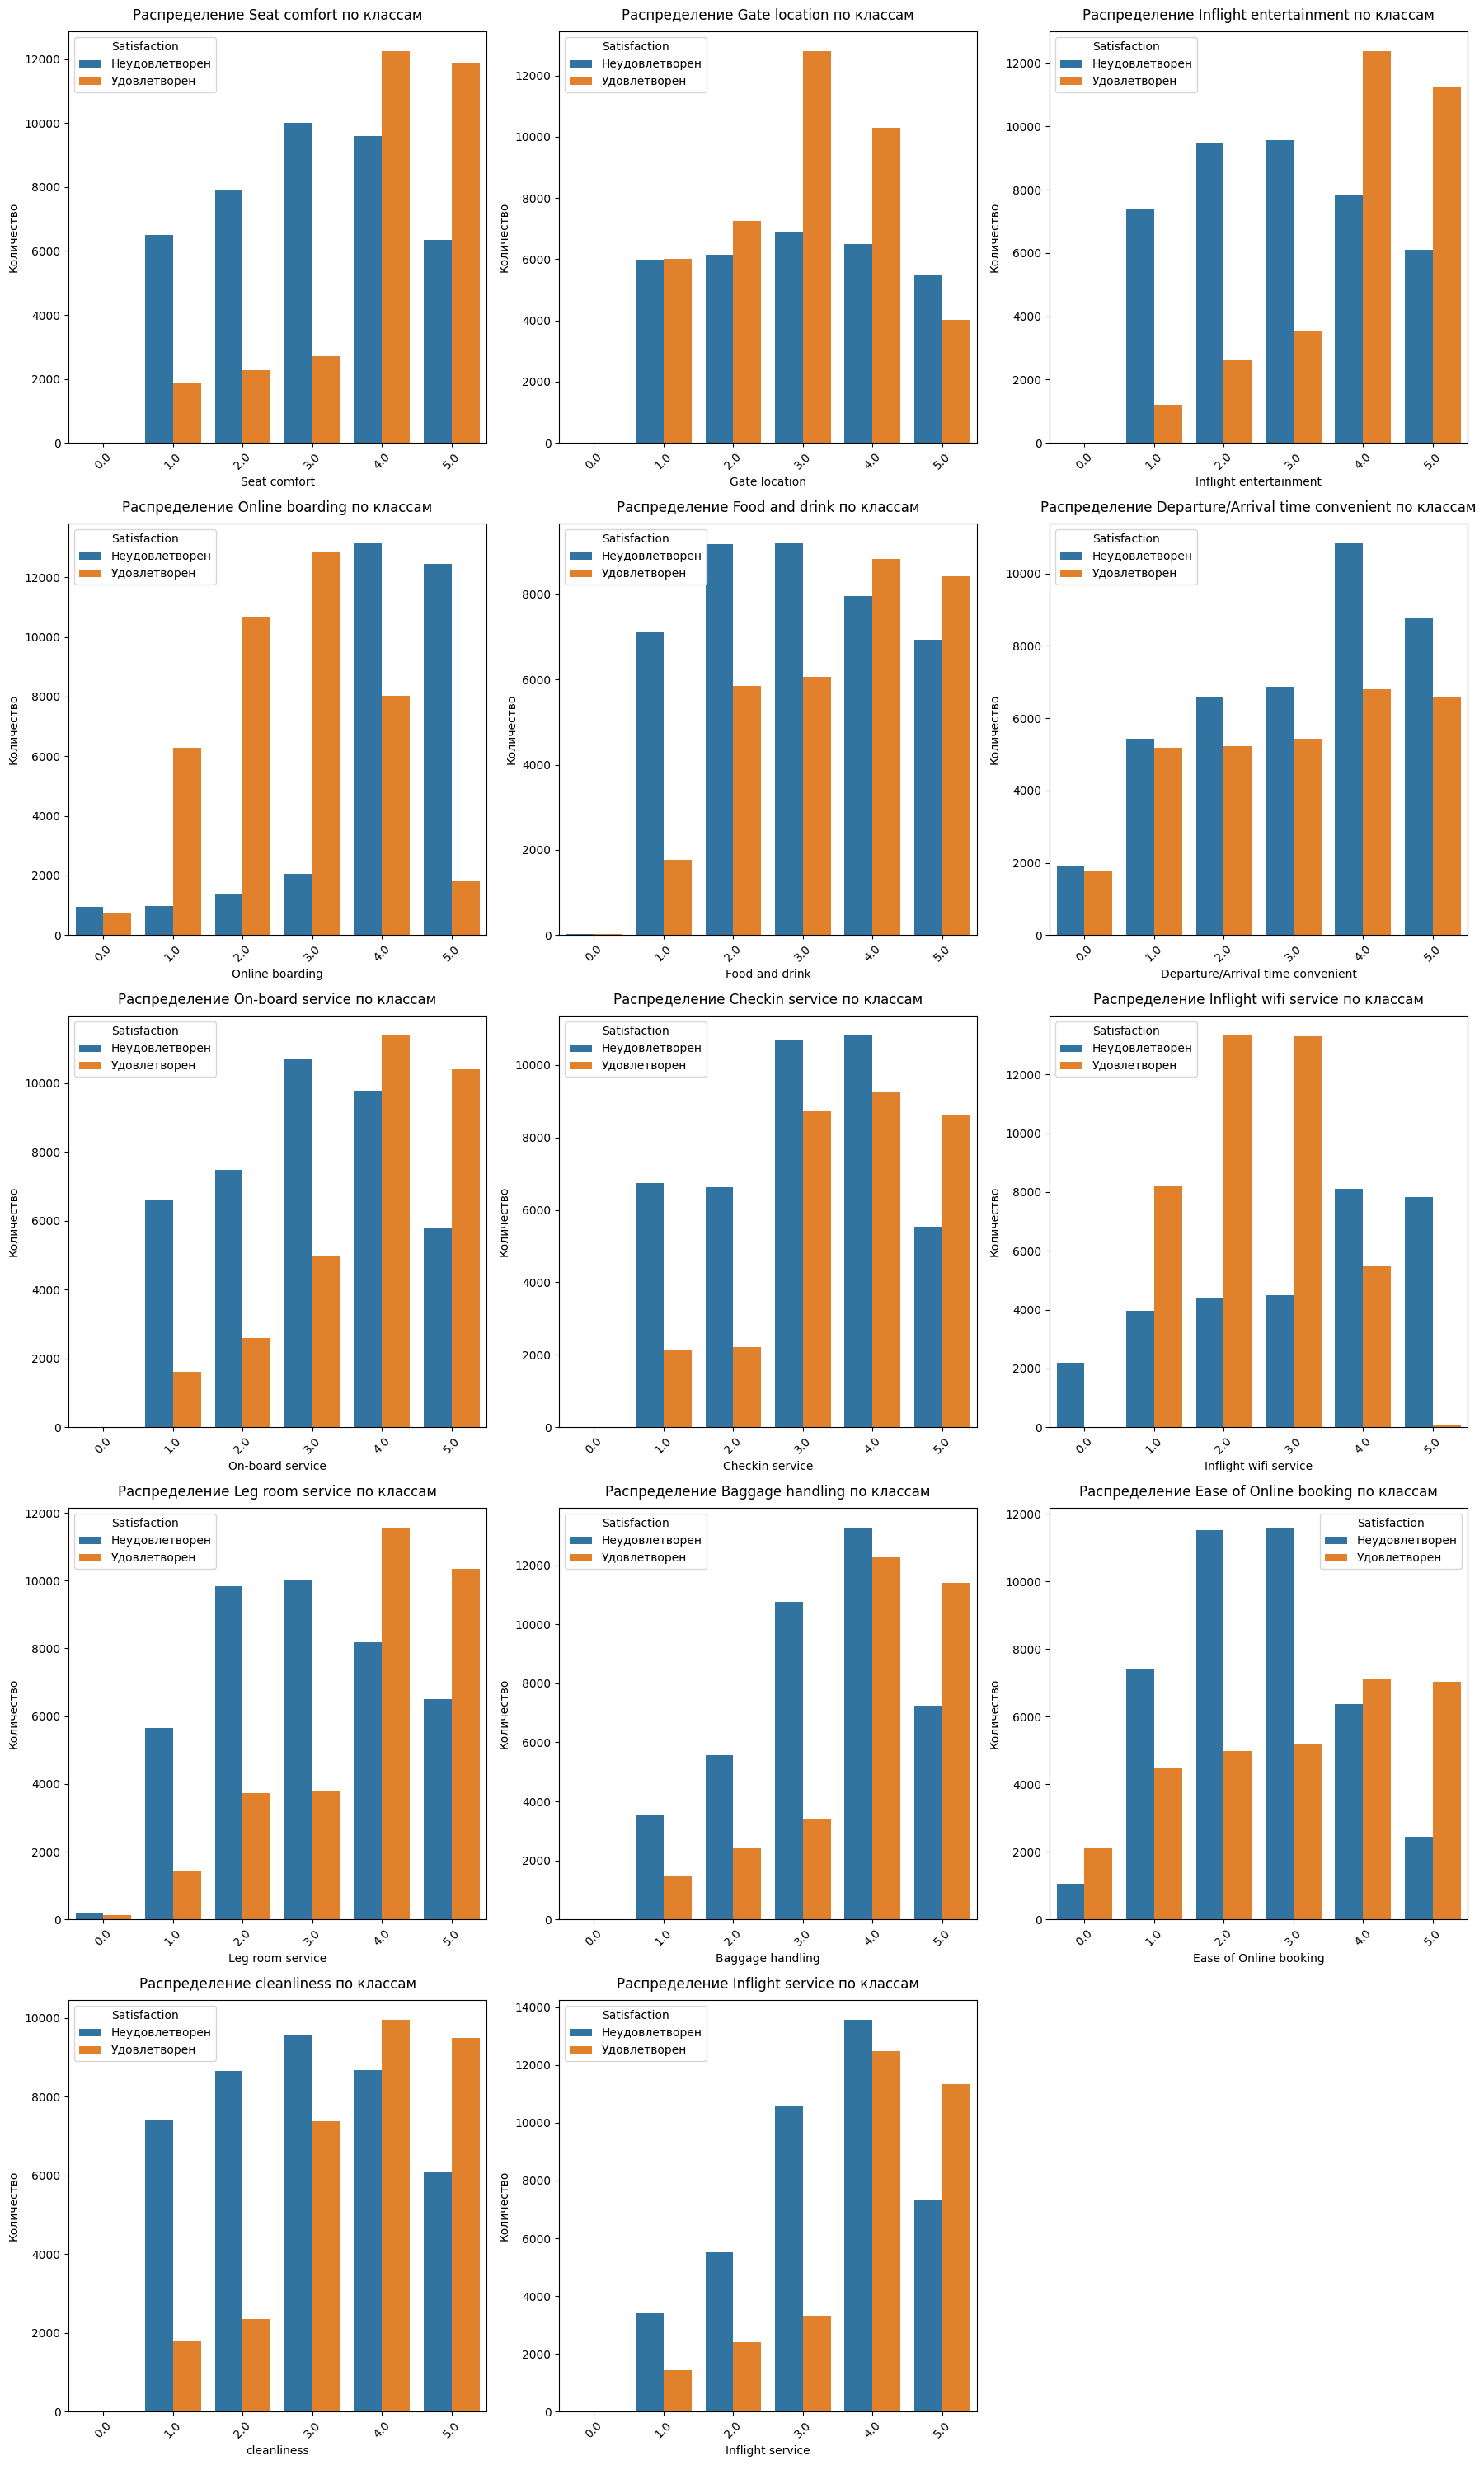

In [44]:
plot_ordinal(ordinal_cols, X_train, y_train)

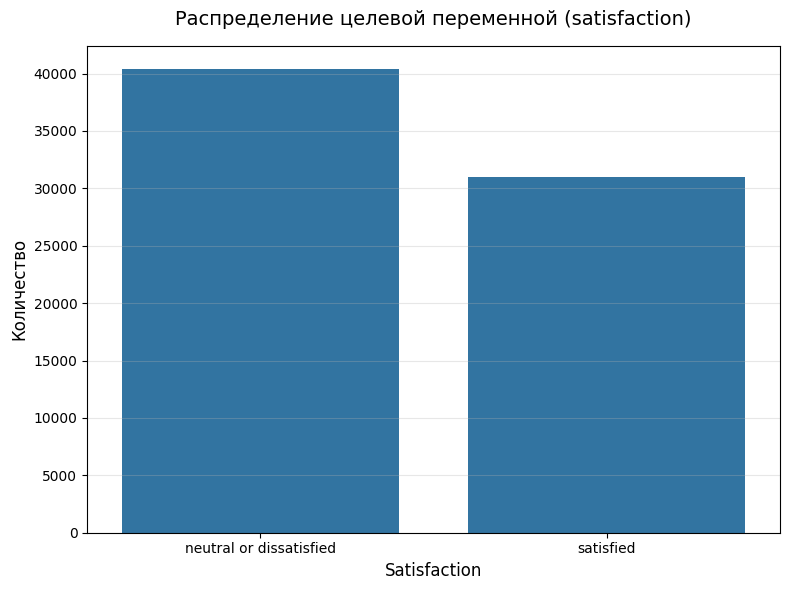

Распределение классов:
satisfaction
neutral or dissatisfied    40395
satisfied                  30974
Name: count, dtype: int64
Процентное соотношение:
satisfaction
neutral or dissatisfied    56.600205
satisfied                  43.399795
Name: proportion, dtype: float64


In [46]:
# visualize y_train
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train)
plt.title('Распределение целевой переменной (satisfaction)', fontsize=14, pad=15)
plt.xlabel('Satisfaction', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Распределение классов:")
print(y_train.value_counts())
print(f"Процентное соотношение:")
print(y_train.value_counts(normalize=True) * 100)

### **Задание 8 (0.2 балла)**

Сделайте выводы по построенным графикам.

Не забудьте упомянуть:
* какие признаки распределены неравномерно
* сбалансированы ли классы
* какие распределения имеют континуальные признаки


**Выводы по построенным графикам:**

**Неравномерно распределенные признаки:**
- **Customer Type**: Сильный дисбаланс - подавляющее большинство клиентов "Loyal Customer" (~81.76%), что может влиять на предсказательную способность
- **Type of Travel**: Неравномерное распределение - большинство путешествий по бизнесу (~69%), меньше личных (~31%).
- **class**: Неравномерное распределение - Business и Eco классы примерно равны (~47% и ~46%), но Eco Plus значительно меньше (~7%).
- **Порядковые признаки (рейтинги сервисов)**: Большинство оценок сосредоточены в диапазоне 2-4, это указывает на средние оценки. Распределения похожи между признаками
- **Задержки рейсов**: Сильно правостороннее распределение с большим количеством нулевых значений (большинство рейсов без задержек)

**Балансировка классов:**
- Классы **несбалансированы**: ~56.6% "neutral or dissatisfied" и ~43.4% "satisfied". Это умеренный дисбаланс, который может потребовать использования техник балансировки при обучении 

**Распределения континуальных признаков:**
- **age**: Близко к нормальному распределению с небольшим смещением вправо. Средний возраст около 40-45 лет. Удовлетворенные и неудовлетворенные клиенты имеют схожее распределение по возрасту.
- **Flight Distance**: Сильно правостороннее распределение (положительная асимметрия). Большинство полетов на короткие и средние расстояния. Есть длинные перелеты, которые могут быть выбросами.
- **Departure Delay in Minutes / Arrival Delay in Minutes**: Экстремально правостороннее распределение с большим количеством нулевых значений. Большинство рейсов без задержек, но есть экстремальные выбросы (задержки до нескольких тысяч минут). После логарифмического преобразования распределение становится более нормальным и лучше видна разница между классами.

**Общие наблюдения:**
- Удовлетворенные клиенты чаще имеют более высокие оценки сервисов (особенно видно на порядковых признаках)
- Бизнес-путешественники и клиенты Business класса чаще удовлетворены
- Задержки рейсов негативно влияют на удовлетворенность клиентов

### **Бонус (0.1 балла)**
По графикам (каким, решите сами) оцените, похожи ли оказались распределения признаков при разбиении на трейн, валидацию и тест.

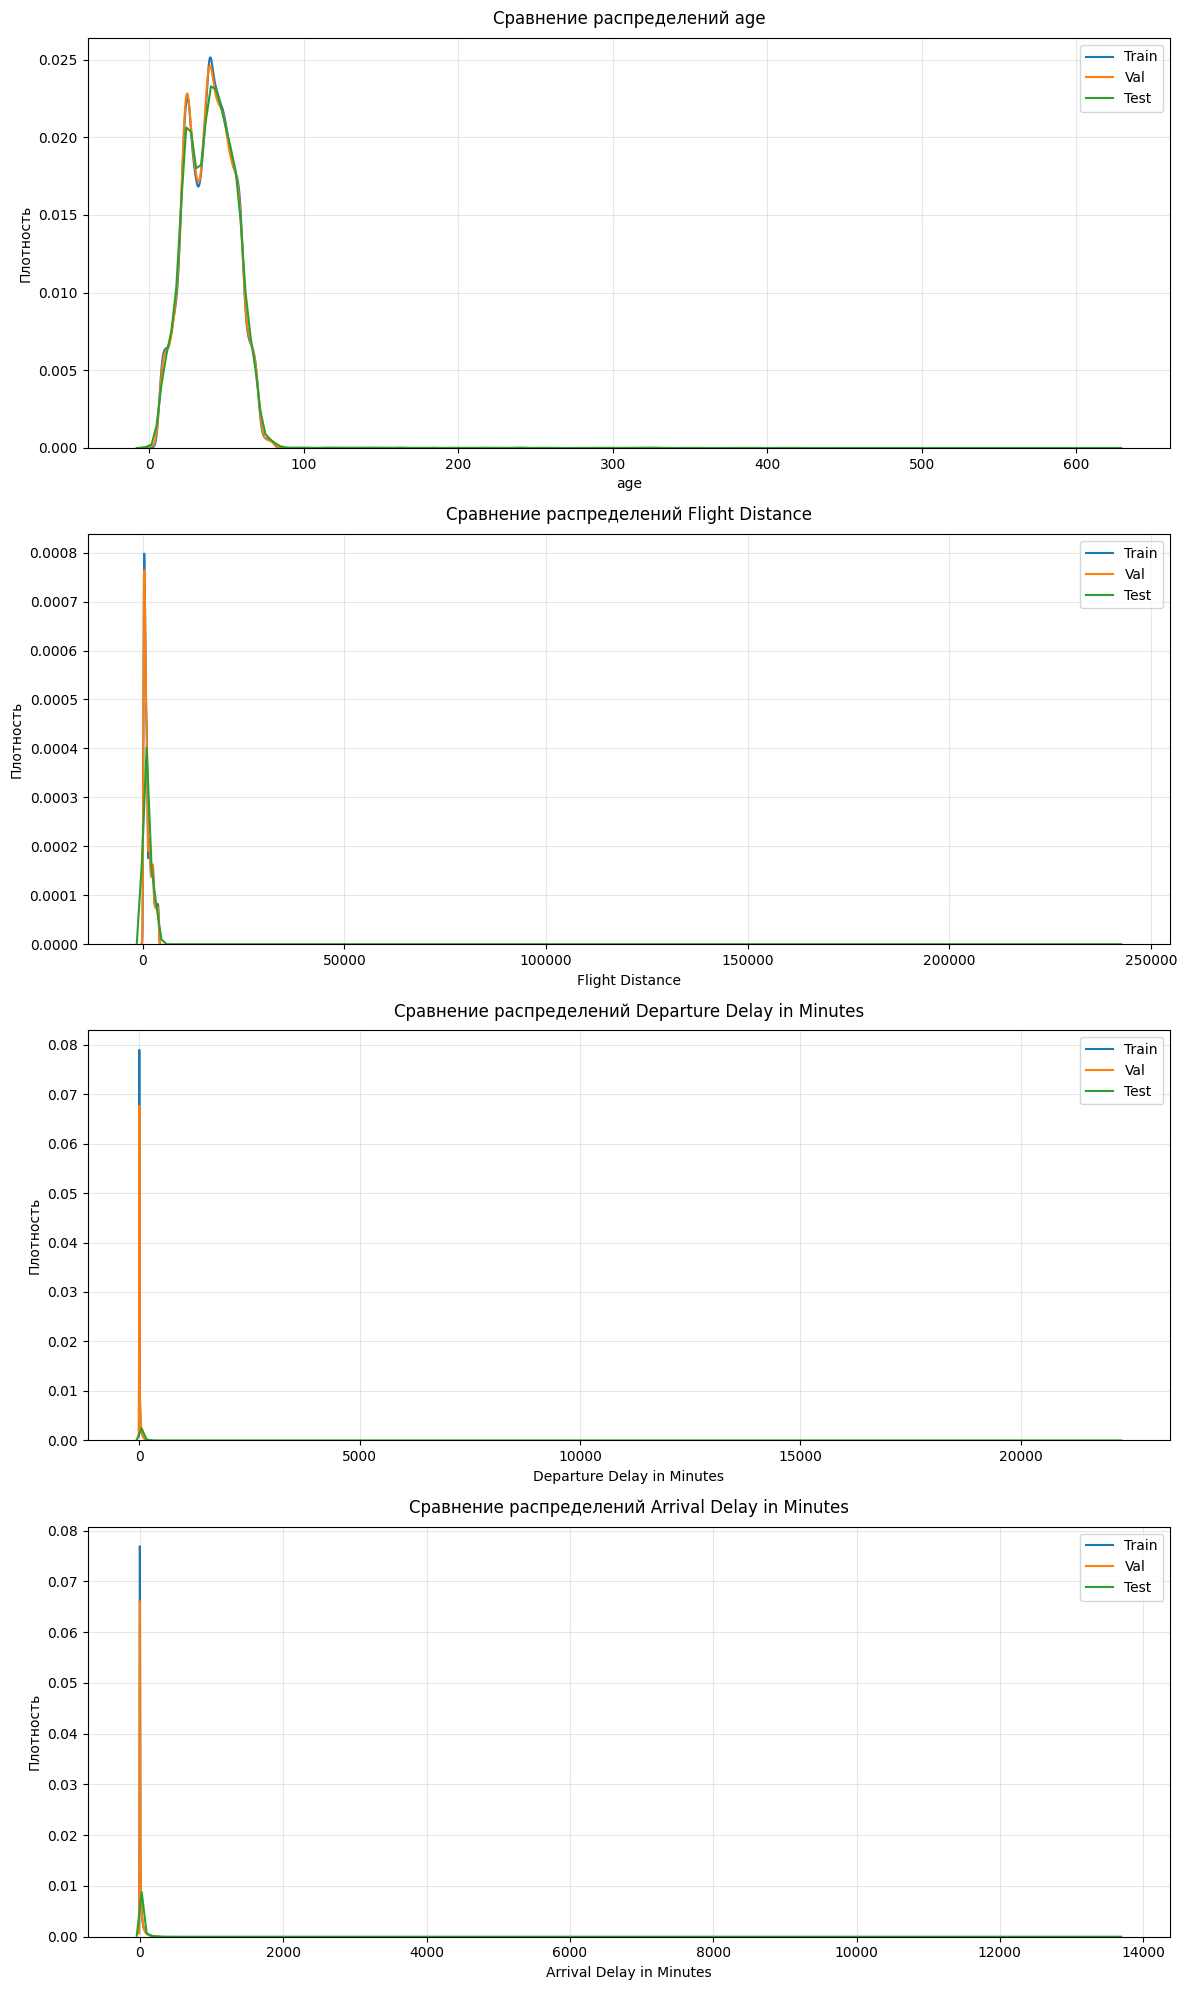

In [47]:
# Для числовых признаков
fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(12, 5 * len(continuous_cols)))
if len(continuous_cols) == 1:
    axes = [axes]

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    sns.kdeplot(data=X_train, x=col, label='Train', ax=ax)
    sns.kdeplot(data=X_val, x=col, label='Val', ax=ax)
    sns.kdeplot(data=df_test, x=col, label='Test', ax=ax)
    ax.set_title(f'Сравнение распределений {col}', fontsize=12, pad=10)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Плотность', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

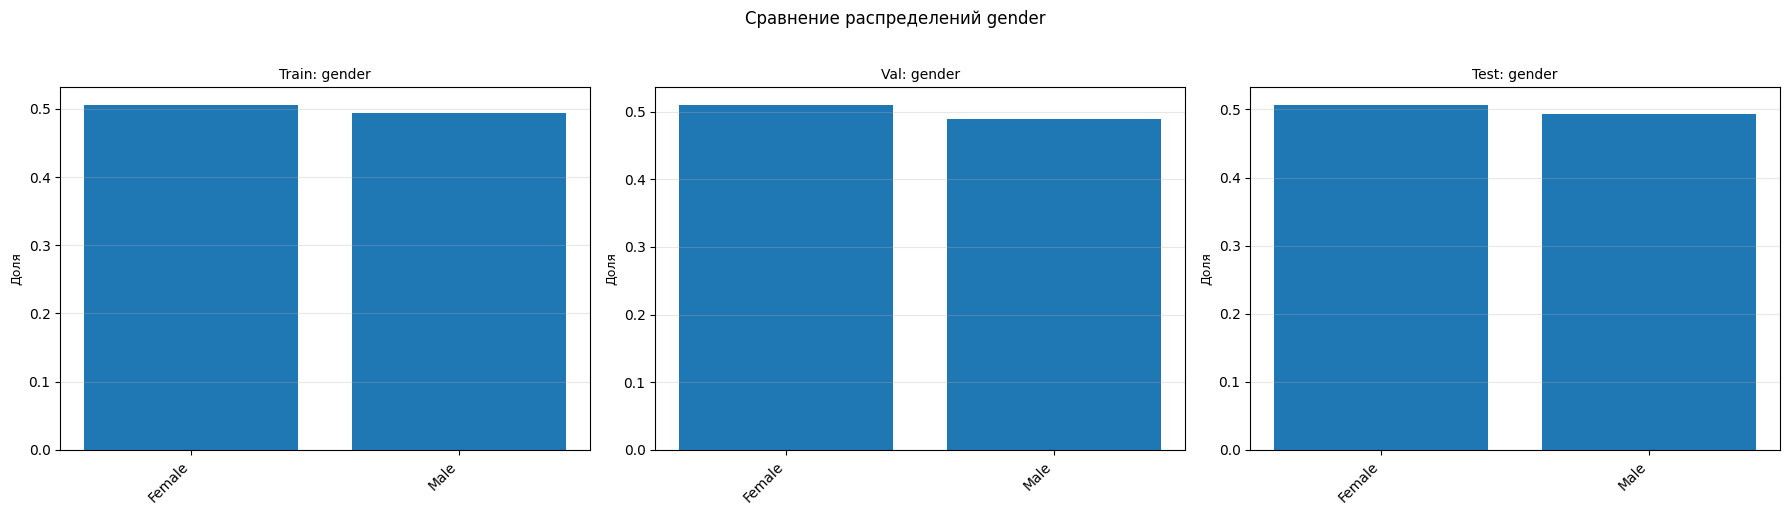

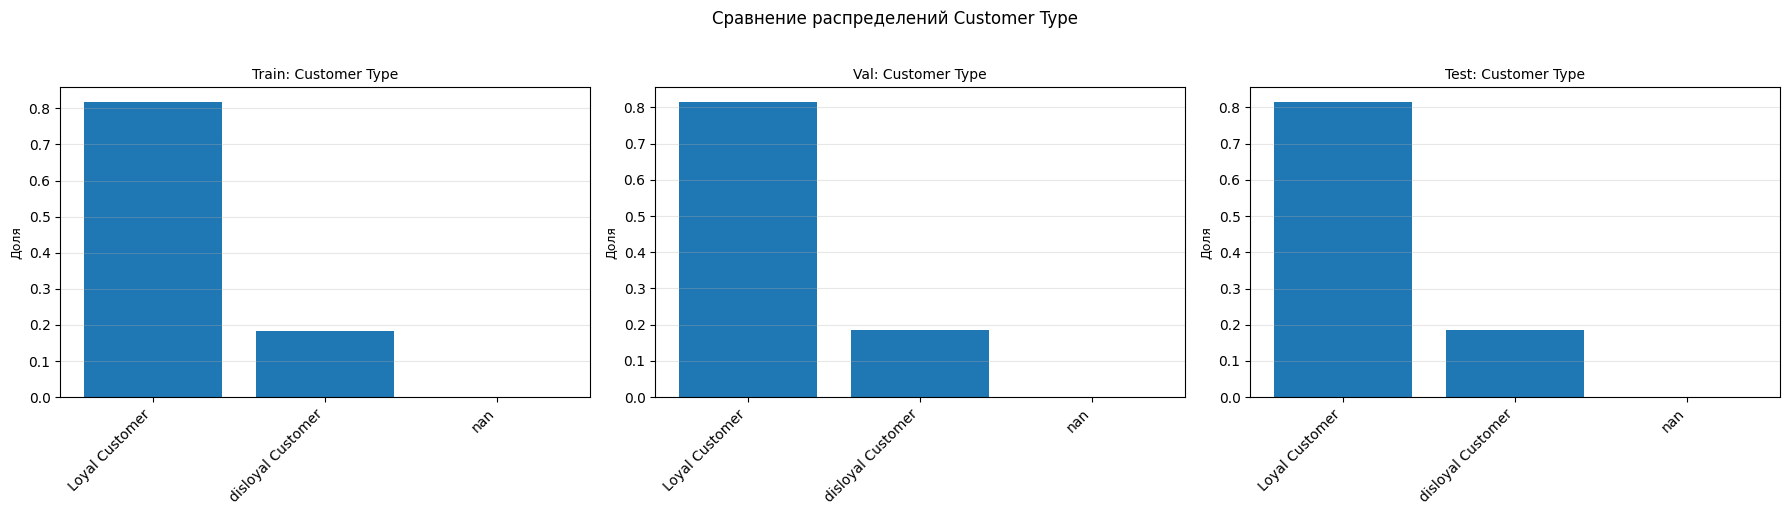

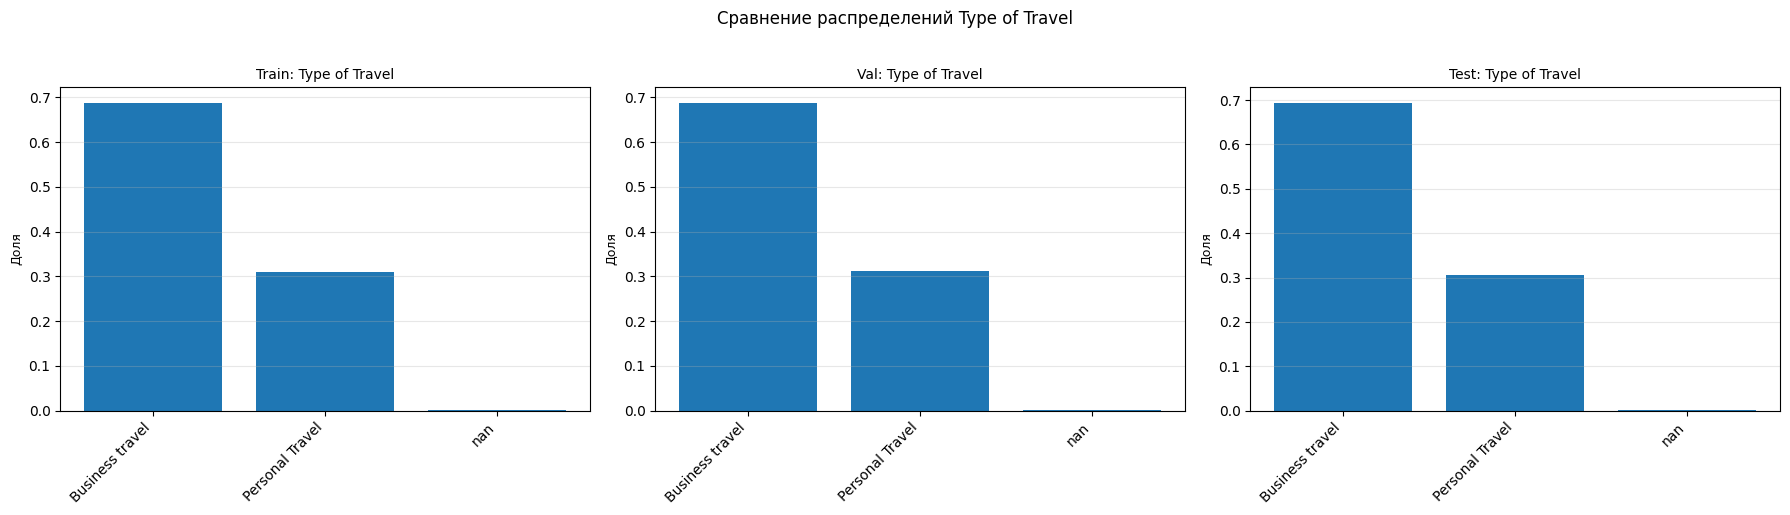

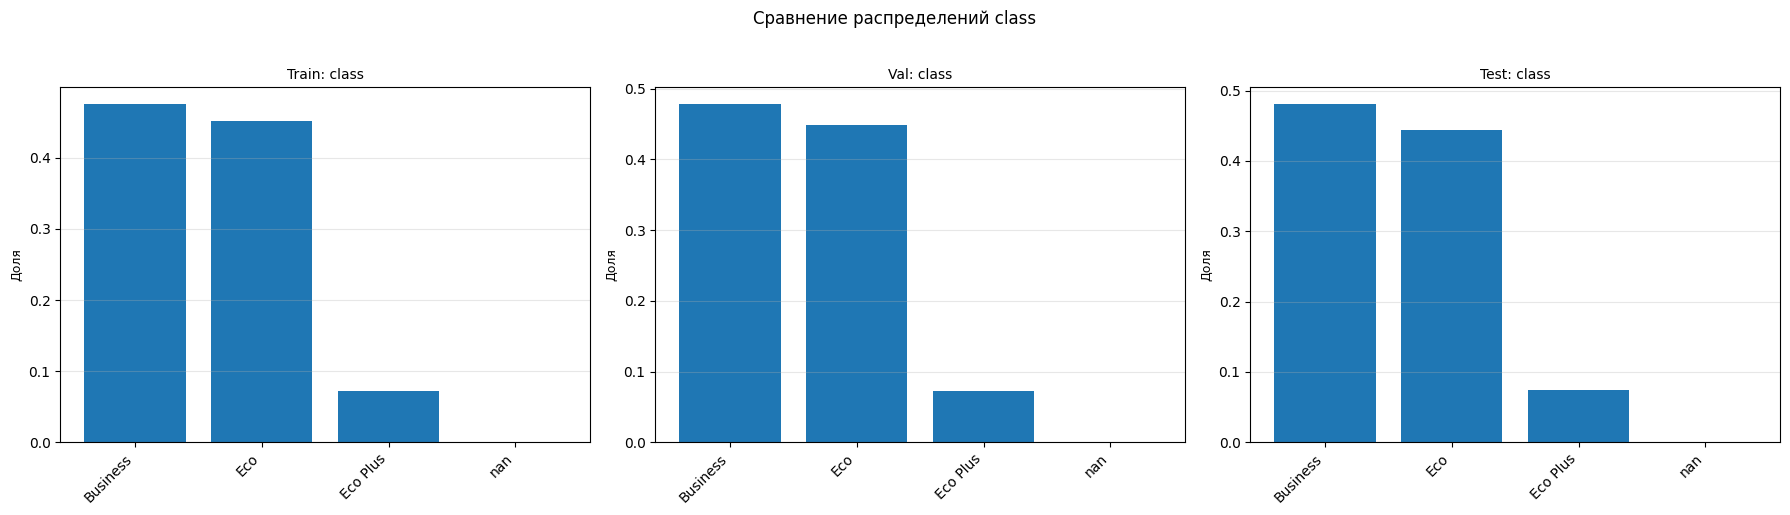

In [48]:
# Для категориальных признаков - сравним доли значений
for col in categorical_cols[:5]:  # Показываем первые 5, чтобы не перегружать
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (name, data) in enumerate([('Train', X_train), ('Val', X_val), ('Test', df_test)]):
        value_counts = data[col].value_counts(normalize=True)
        axes[idx].bar(range(len(value_counts)), value_counts.values)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{name}: {col}', fontsize=10)
        axes[idx].set_ylabel('Доля', fontsize=9)
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Сравнение распределений {col}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- Числовые признаки (age, Flight Distance, Departure Delay, Arrival Delay):
  - Распределения Train, Val и Test почти совпадают. KDE для всех четырёх признаков идут рядом, значит разбиение сохраняет структуру данных. Для age — два пика (20–30 и 40–50 лет), для задержек и дистанции — пик около нуля и длинный хвост вправо. Это говорит о том, что выборки репрезентативны и модель, обученная на Train, будет видеть похожие распределения на Val и Test.
- Категориальный признак (gender):
  - Доли Female (~51%) и Male (~49%) в Train, Val и Test почти одинаковы. Баланс классов сохраняется при разбиении, что важно для корректной оценки качества и отсутствия смещения по полу.
Итог: Разбиение на Train/Val/Test выполнено как мне кажется корректно: распределения признаков и долей категорий стабильны по выборкам. Это снижает риск утечки данных и повышает шансы на хорошую генерализацию модели

### **Задание 9 (0.25 балла)**

- Замените признаки "Departure Delay in Minutes" и "Arrival Delay in Minutes" на их логарифмы.
- Заново постройте графики континуальных признаков и сделайте вывод по преобразованию

Некоторые признаки полезно рассматривать в логарифмической шкале. Зачем? Она помогает анализировать большие диапазоны изменений (посмотрите на график логарифма).


In [61]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

In [62]:
# Заменяем признаки на их логарифмы
# Добавляем 1, чтобы избежать проблем с нулевыми значениями
X_train['Departure Delay in Minutes_log'] = np.log1p(X_train['Departure Delay in Minutes'].astype(float))
X_train['Arrival Delay in Minutes_log'] = np.log1p(X_train['Arrival Delay in Minutes'].astype(float))

X_val['Departure Delay in Minutes_log'] = np.log1p(X_val['Departure Delay in Minutes'].astype(float))
X_val['Arrival Delay in Minutes_log'] = np.log1p(X_val['Arrival Delay in Minutes'].astype(float))

KeyError: 'Departure Delay in Minutes'

In [ ]:
X_train = X_train.drop(['Departure Delay in Minutes', 'Arrival Delay in Minutes'], axis=1)
X_val = X_val.drop(['Departure Delay in Minutes', 'Arrival Delay in Minutes'], axis=1)

# Обновляем список континуальных признаков
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes_log', 'Arrival Delay in Minutes_log']

print("Признаки успешно преобразованы в логарифмическую шкалу")
print(f"Новые размеры: X_train {X_train.shape}, X_val {X_val.shape}")

Признаки успешно преобразованы в логарифмическую шкалу
Новые размеры: X_train (71369, 22), X_val (30591, 22)


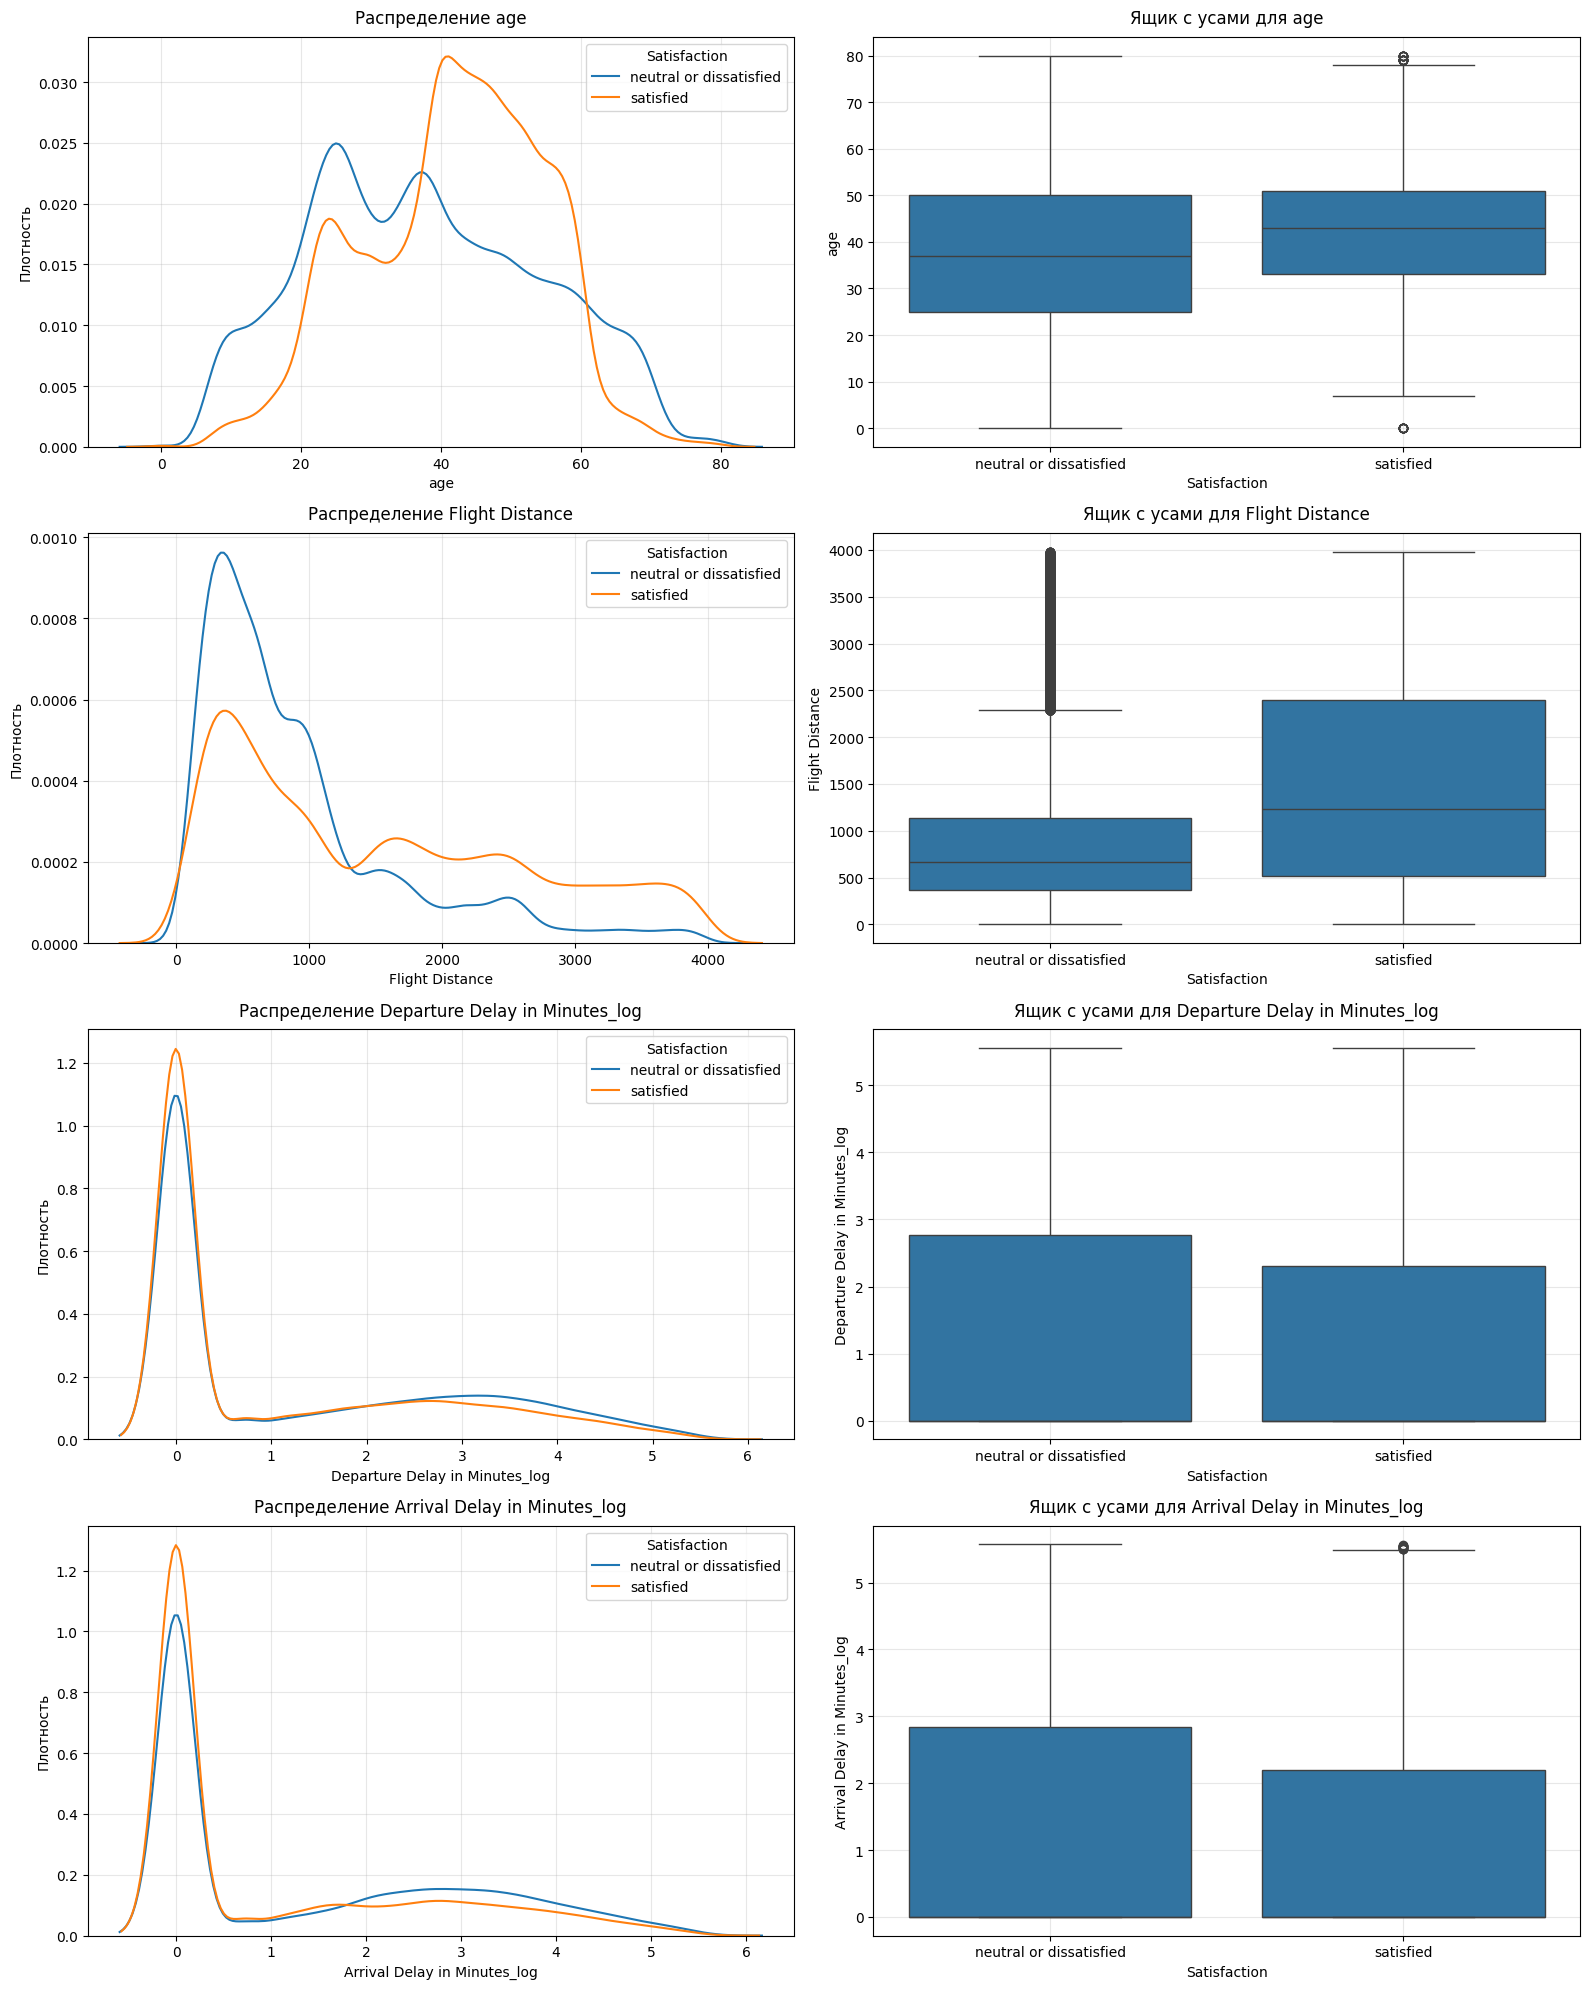

In [ ]:
plot_continuous(continuous_cols, X_train, y_train)

**Вывод по преобразованию:** После логарифмирования (log1p) признаки Departure Delay и Arrival Delay имеют более сжатое и приближённо нормальное распределение. Исходные задержки были сильно правоскошенными: большинство значений около нуля и длинный хвост до тысяч минут. Логарифм сжимает этот диапазон и делает распределение более удобным для алгоритмов, чувствительных к масштабу. На графиках лучше видна разница между удовлетворёнными и неудовлетворёнными клиентами в области малых и средних задержек.

### **Задание 10 (0.25 балла)**

Выше вы рассмотрели `boxplot` и графики распределений. Но иногда полезным оказывается `scatterplot, (pairplot)` в seabron. Проверьте, что покажет этот график в нашей задаче.

- Отобразите попарное распределение континуальных (по договоренности) признаков. Покрасьте точки на pairplot'е в соответствии с их классом.

**Примечание:**
Наблюдений много, так что отрисовка графика вполне может занять несколько минут

In [63]:
# Покрасим точки в соответствии с классом

# Создаем временный датафрейм с континуальными признаками и таргетом
pairplot_data = X_train[continuous_cols].copy()
pairplot_data['satisfaction'] = y_train

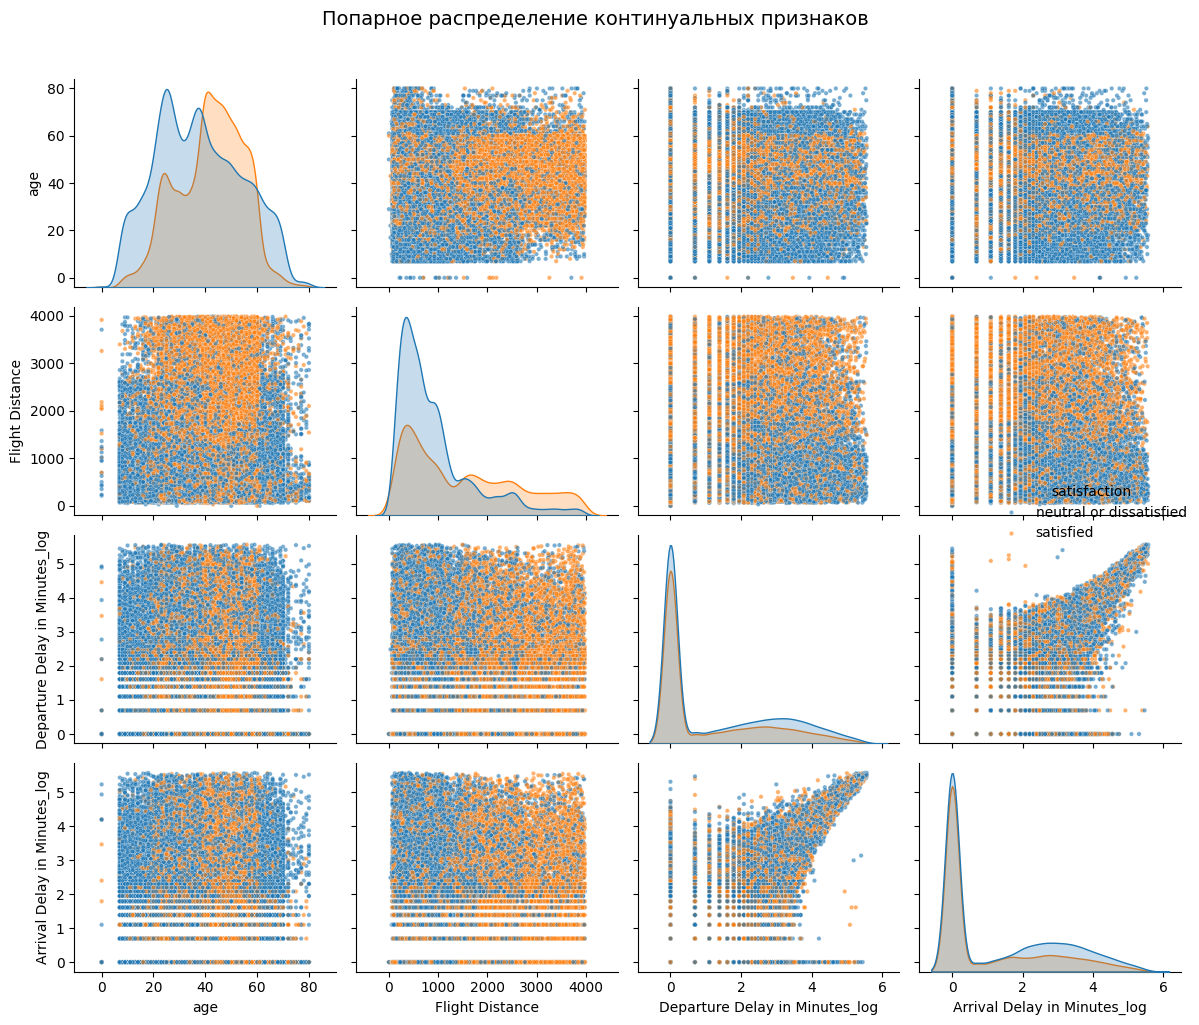

In [64]:
sns.pairplot(pairplot_data, hue='satisfaction', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 10})
plt.suptitle('Попарное распределение континуальных признаков', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# **Часть 2. Decision Tree (3 балла)**

### **Задание 11 (0.4 балла)**

Предобработайте данные для алгоритма.
- Закодируйте таргет таким образом, чтоб 'satisfied' перешел в 1, а остальные значения в 0;
- Закодируйте категориальные признаки методом OHE;

In [65]:
# Кодирование таргета: 'satisfied' -> 1, остальные -> 0
y_train_encoded = (y_train == 'satisfied').astype(int)
y_val_encoded = (y_val == 'satisfied').astype(int)

print(f"Распределение таргета в train: {y_train_encoded.value_counts().to_dict()}")
print(f"Распределение таргета в val: {y_val_encoded.value_counts().to_dict()}")


Распределение таргета в train: {0: 40395, 1: 30974}
Распределение таргета в val: {0: 17456, 1: 13135}


In [66]:
from sklearn.preprocessing import OneHotEncoder

# Выделяем категориальные признаки
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки для OHE: {categorical_cols}")

# Создаем OHE encoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Применяем OHE к train и val
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_val_cat = ohe.transform(X_val[categorical_cols])

# Получаем имена новых признаков
feature_names = ohe.get_feature_names_out(categorical_cols)

# Создаем датафреймы с закодированными категориальными признаками
X_train_cat_df = pd.DataFrame(X_train_cat, columns=feature_names, index=X_train.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=feature_names, index=X_val.index)


Категориальные признаки для OHE: ['gender', 'Customer Type', 'Type of Travel', 'class']


In [67]:
# Объединяем числовые и закодированные категориальные признаки
numeric_cols = X_train.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns.tolist()
X_train_enc = pd.concat([X_train[numeric_cols], X_train_cat_df], axis=1)
X_val_enc = pd.concat([X_val[numeric_cols], X_val_cat_df], axis=1)

print(f"Размер X_train после OHE: {X_train_enc.shape}")
print(f"Размер X_val после OHE: {X_val_enc.shape}")
print(f"Первые несколько столбцов: {list(X_train_enc.columns[:10])}")

Размер X_train после OHE: (71369, 26)
Размер X_val после OHE: (30591, 26)
Первые несколько столбцов: ['age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment']


### **Задание 12. (0.1 балла)**

- Обучите дерево решений с параметрами по умолчанию на имеющихся данных.
- Выведите `accuracy_score` для валидационной подвыборки

**Примечание**:

Здесь и далее, где вас просят что-нибудь обучить, выводите **везде** `accuracy_score` для валидационной подвыборки.

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_enc, y_train_encoded)

y_val_pred = dt_default.predict(X_val_enc)

val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
print(f"Accuracy на валидационной выборке: {val_accuracy:.4f}")

y_train_pred = dt_default.predict(X_train_enc)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
print(f"Accuracy на тренировочной выборке: {train_accuracy:.4f}")
print(f"Разница (переобучение): {train_accuracy - val_accuracy:.4f}")

Accuracy на валидационной выборке: 0.9437
Accuracy на тренировочной выборке: 1.0000
Разница (переобучение): 0.0563


## **Анализ построенной модели**

### **Задание 13. (0.5 балла)**

- Посчитайте bias и variance для построенного дерева. Для этого проще всего вспользоваться функцией `bias_variance_decomp()` из модуля mlxtend. Используйте '0-1_loss'

In [69]:
from mlxtend.evaluate import bias_variance_decomp


error_dt, bias_dt, var_dt = bias_variance_decomp(
    dt_default, 
    X_train_enc.values, 
    y_train_encoded.values, 
    X_val_enc.values, 
    y_val_encoded.values,
    loss='0-1_loss',
    random_seed=42
)

print(f"Ошибка (Error): {error_dt:.4f}")
print(f"Смещение (Bias): {bias_dt:.4f}")
print(f"Дисперсия (Variance): {var_dt:.4f}")
print(f"Сумма bias и variance: {bias_dt + var_dt:.4f}")
print(f"Разница с общей ошибкой: {abs(error_dt - (bias_dt + var_dt)):.6f}")

Ошибка (Error): 0.0606
Смещение (Bias): 0.0398
Дисперсия (Variance): 0.0443
Сумма bias и variance: 0.0842
Разница с общей ошибкой: 0.023619


### **Задание 14. (0.2 балла)**

Проанализируйте структурные характеристики дерева.
- Какой глубины получилось дерево?
- Сколько в нем листьев?

In [70]:
max_depth = dt_default.tree_.max_depth
n_leaves = dt_default.tree_.n_leaves
n_nodes = dt_default.tree_.node_count

print(f"Глубина дерева: {max_depth}")
print(f"Количество листьев: {n_leaves}")
print(f"Общее количество узлов: {n_nodes}")
print(f"Количество внутренних узлов: {n_nodes - n_leaves}")

print(f"Минимальное количество образцов в листе: {dt_default.min_samples_leaf}")
print(f"Минимальное количество образцов для разделения: {dt_default.min_samples_split}")

Глубина дерева: 35
Количество листьев: 2087
Общее количество узлов: 4173
Количество внутренних узлов: 2086
Минимальное количество образцов в листе: 1
Минимальное количество образцов для разделения: 2


### **Задание 15. (0.3 балла)**

Проанализируйте важность признаков, вычисляемую в дереве по построению.

- Выведите на экран barplot, демонстрирующий оценки важности признаков.
- Укажите, какие признаки оказались наиболее информативными?

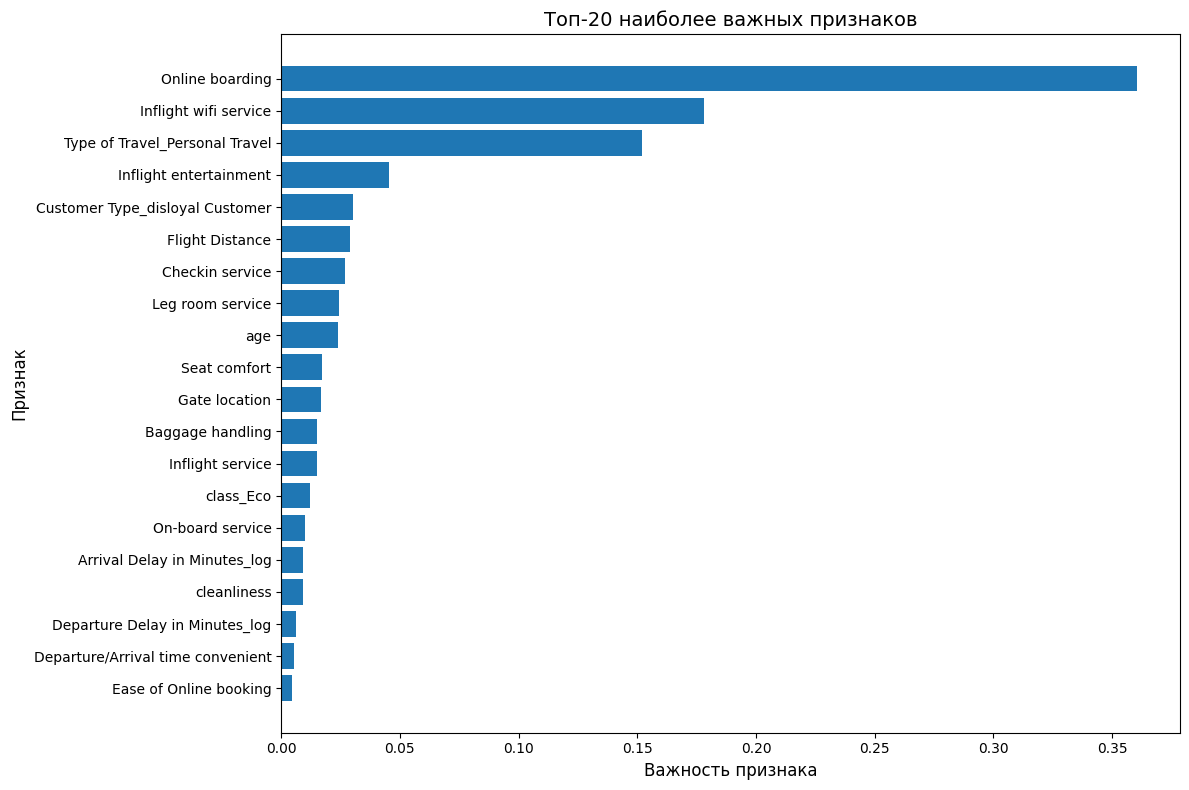

Топ-10 наиболее важных признаков:
                        feature  importance
                Online boarding    0.360594
          Inflight wifi service    0.177922
 Type of Travel_Personal Travel    0.151911
         Inflight entertainment    0.045450
Customer Type_disloyal Customer    0.030078
                Flight Distance    0.028800
                Checkin service    0.027096
               Leg room service    0.024233
                            age    0.023768
                   Seat comfort    0.017343


In [ ]:
# Получаем важности признаков
feature_importances = dt_default.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Важность признака', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title(f'Топ-{top_n} наиболее важных признаков', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 наиболее важных признаков:")
print(importance_df.head(10).to_string(index=False))

**Наиболее информативные признаки:**

Судя по важности признаков, наиболее информативными оказались:

1. **Оценки сервисов** (особенно `Online boarding`, `Inflight wifi service`, `Seat comfort`, `Food and drink`) - эти признаки имеют наибольшую важность, что логично, так как они напрямую связаны с удовлетворенностью клиентов.

2. **Тип путешествия** (`Type of Travel_Business travel`) - бизнес-путешественники чаще бывают удовлетворены.

3. **Класс обслуживания** (`class_Business`) - клиенты бизнес-класса чаще удовлетворены.

4. **Возраст** (`age`) - также является важным признаком.

5. **Расстояние полета** (`Flight Distance`) - влияет на удовлетворенность.

Наименее важными оказались некоторые категориальные признаки после OHE и некоторые оценки сервисов с низкой вариативностью.

### **Задание 16. (0.1 балла)**

- Постройте дерево глубины 5, используя только 2 наиболее информативных признака для предыдущего построенного дерева.

In [71]:
# Берем 2 наиболее информативных признака
top_2_features = importance_df.head(2)['feature'].tolist()
print(f"Два наиболее информативных признака: {top_2_features}")

# Создаем подвыборки с только этими признаками
X_train_2feat = X_train_enc[top_2_features]
X_val_2feat = X_val_enc[top_2_features]

# Обучаем дерево глубины 5 на этих признаках
dt_2feat = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_2feat.fit(X_train_2feat, y_train_encoded)

# Предсказания и оценка
y_train_pred_2feat = dt_2feat.predict(X_train_2feat)
y_val_pred_2feat = dt_2feat.predict(X_val_2feat)

train_acc_2feat = accuracy_score(y_train_encoded, y_train_pred_2feat)
val_acc_2feat = accuracy_score(y_val_encoded, y_val_pred_2feat)

print(f"Accuracy на train: {train_acc_2feat:.4f}")
print(f"Accuracy на val: {val_acc_2feat:.4f}")
print(f"Глубина дерева: {dt_2feat.tree_.max_depth}")
print(f"Количество листьев: {dt_2feat.tree_.n_leaves}")

Два наиболее информативных признака: ['Online boarding', 'Inflight wifi service']
Accuracy на train: 0.8211
Accuracy на val: 0.8218
Глубина дерева: 5
Количество листьев: 18


### **Задание 17. (0.15 балла)**

- С помощью graphviz визуализируйте получившееся новое дерево решений. Почему предикаты в нем не целые, а кратны 1/2?

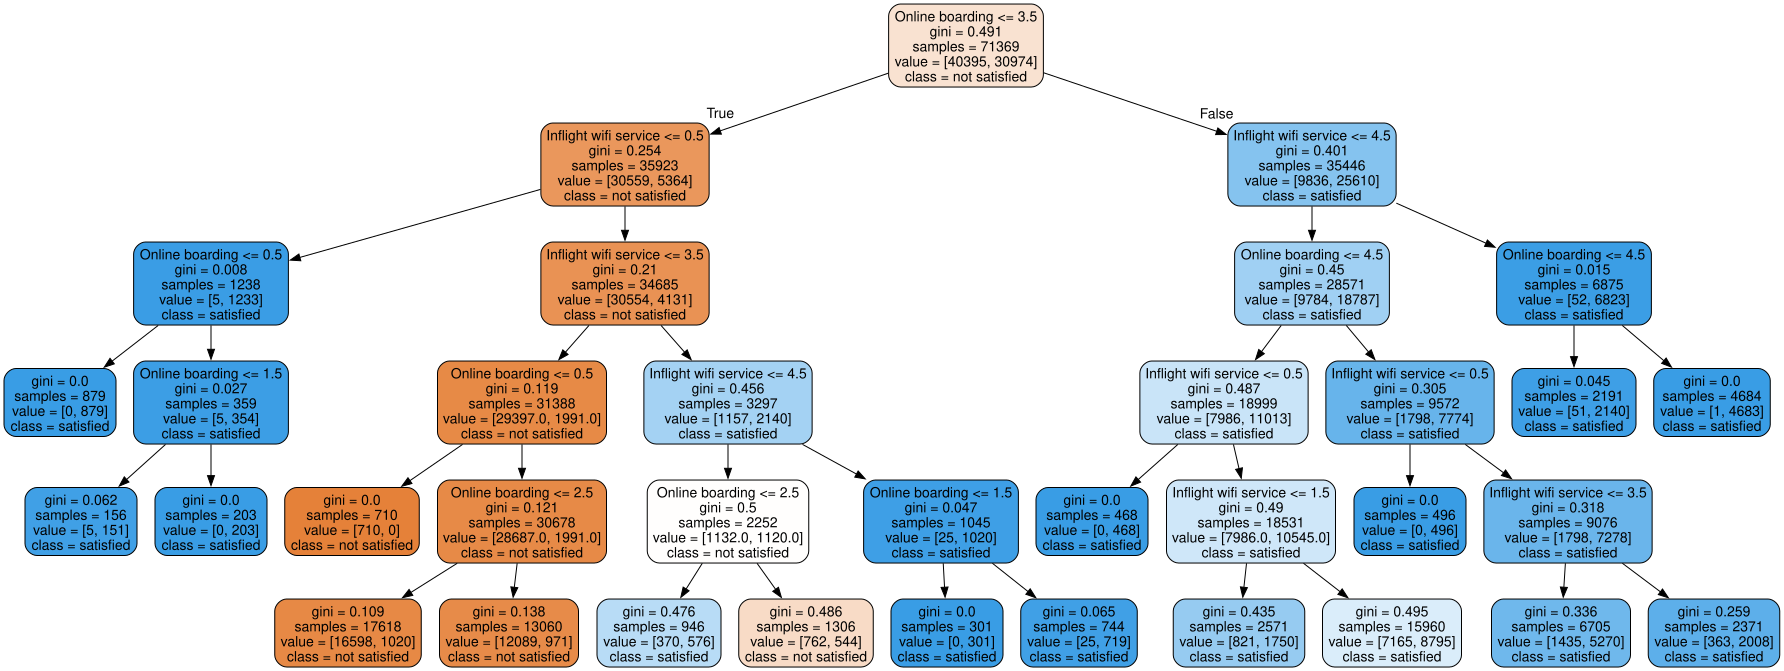

In [83]:
dot_data = export_graphviz(
    dt_2feat,
    out_file=None,
    feature_names=top_2_features,
    class_names=['not satisfied', 'satisfied'],
    filled=True,
    rounded=True
)
graph = Source(dot_data)
display(SVG(graph.pipe(format='svg')))

# Экспорт в PDF (output.pdf)
graph.render('output', format='pdf', cleanup=True)
from IPython.display import IFrame
display(IFrame('output.pdf', width=800, height=600))

In [82]:
# !brew install graphviz

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
actions-up: Tool to update GitHub Actions to latest versions with SHA pinning
agent-browser: Browser automation CLI for AI agents
aoe: Terminal session manager for AI coding agents
apache-serf: High-performance asynchronous HTTP client library
arcadedb: Multi-Model DBMS: Graph, Document, Key/Value, Search, Time Series, Vector
asc: Fast, lightweight CLI for App Store Connect
bagel: CLI to audit posture and evaluate compromise blast radius
bazel@8: Google's own build tool
claude-agent-acp: Use Claude Code from any ACP client such as Zed!
cozyhr: Cozy wrapper around Helm and Flux CD for local development
datadog-static-analyzer: Static analysis tool for code quality and security
difi: Pixel-per

**Почему предикаты в дереве не целые, а кратны 1/2?**

Предикаты в дереве решений кратны 1/2 (например, 2.5, 3.5, 4.5) потому что:

1. **Дискретные значения признаков**: В нашем случае признаки, которые мы используем (например, оценки сервисов от 0 до 5), являются дискретными целочисленными значениями.

2. **Оптимальные пороги разделения**: Алгоритм дерева решений ищет оптимальные пороги для разделения данных. Когда признак принимает только целые значения (0, 1, 2, 3, 4, 5), оптимальный порог для разделения будет находиться между двумя соседними целыми значениями.

3. **Разделение на два подмножества**: Например, если мы хотим разделить данные по признаку со значениями {0, 1, 2, 3, 4, 5}, то порог 2.5 разделит данные на два подмножества: одно с значениями ≤ 2 (т.е. 0, 1, 2) и другое с значениями > 2 (т.е. 3, 4, 5). Это оптимальный способ разделения для дискретных признаков.

4. **Математическая причина**: Алгоритм CART (Classification and Regression Trees), используемый в sklearn, выбирает пороги как среднее между двумя соседними значениями признака в отсортированном массиве. Для целочисленных признаков это всегда будет значение вида (n + n+1)/2 = n + 0.5.

Таким образом, предикаты кратны 0.5 не из-за ошибки или округления, а потому что это оптимальные пороги разделения для дискретных признаков.

*Источник: Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). Classification and regression trees. CRC press.* (это я нагуглил)

### **Задание 18. (0.25 балла)**

- Теперь отобразите его функцией `plot_tree()` из sklearn.
- Проанализируйте — симметричным ли получилось дерево? И хорошо ли это, или нет?

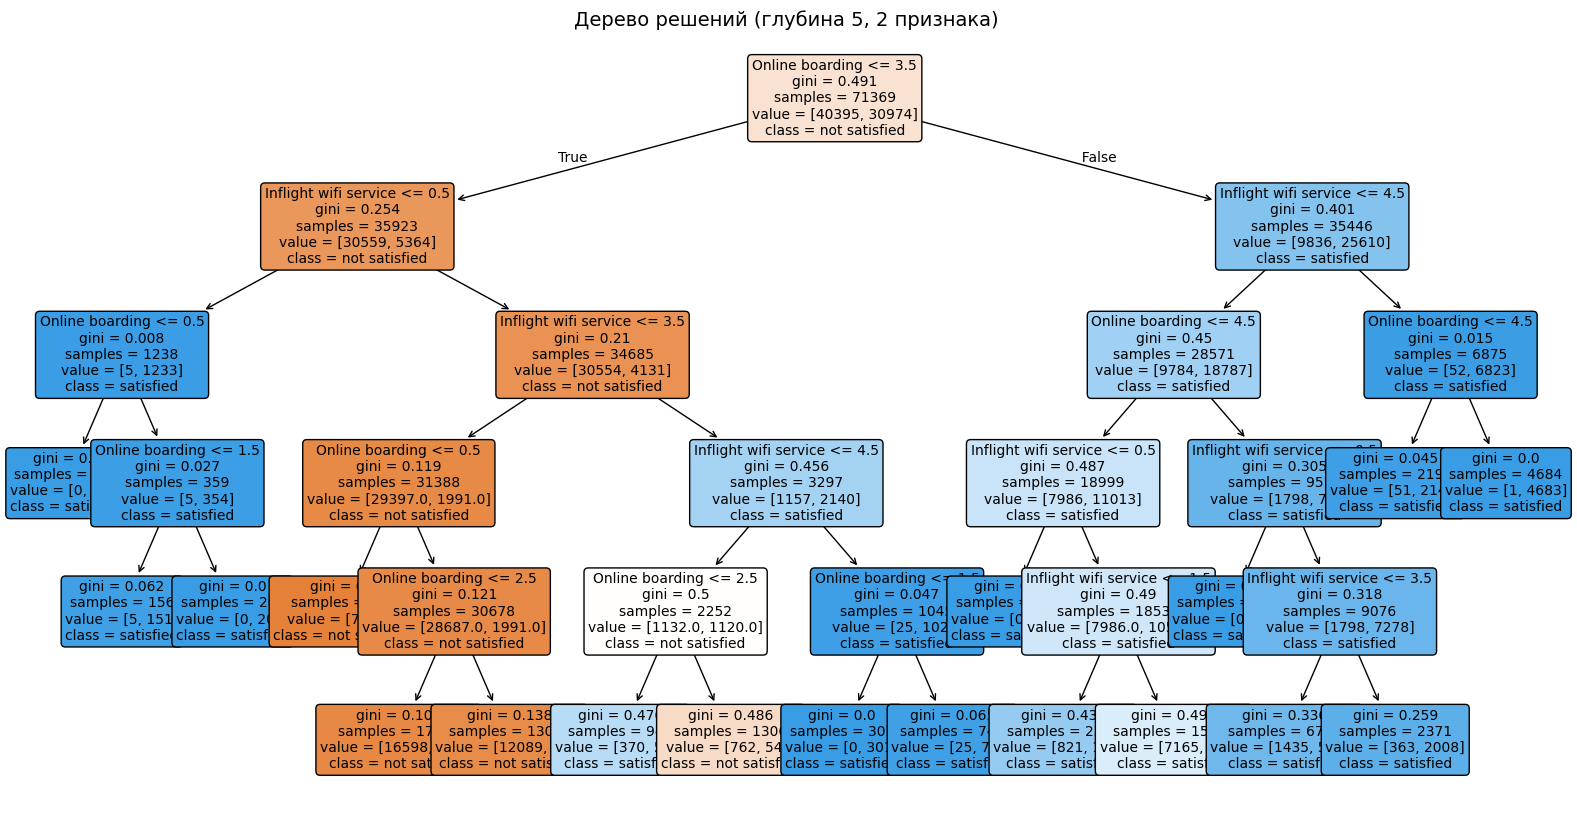

Анализ структуры дерева:
Глубина дерева: 5
Количество листьев: 18
Максимальное количество листьев для полного бинарного дерева глубины 5: 32 = 32


In [72]:
plt.figure(figsize=(20, 10))
plot_tree(dt_2feat, 
          feature_names=top_2_features,
          class_names=['not satisfied', 'satisfied'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Дерево решений (глубина 5, 2 признака)', fontsize=14)
plt.show()

print("Анализ структуры дерева:")
print(f"Глубина дерева: {dt_2feat.tree_.max_depth}")
print(f"Количество листьев: {dt_2feat.tree_.n_leaves}")
print(f"Максимальное количество листьев для полного бинарного дерева глубины 5: {2**5} = 32")

In [75]:
n_leaves = dt_2feat.tree_.n_leaves
max_possible_leaves = 2**dt_2feat.tree_.max_depth
is_symmetric = (n_leaves == max_possible_leaves)

print(f"Дерево {'симметричное' if is_symmetric else 'несимметричное'}")
print(f"Использовано {n_leaves} из {max_possible_leaves} возможных листьев")


Дерево несимметричное
Использовано 18 из 32 возможных листьев


Дерево несимметричное, это означает, что некоторые ветви обрезаны раньше из-за критерия остановки. Возможно это хорошо (тк предотвращает переобучение) или плохо (если важные разбиения не сделаны)

### **Задание 19. (0.5 балла)**

- Используя функцию `plot_decision_regions()` из `mlxtend`, отобразите разделяющую поверхность получившегося дерева. Отметьте на графике только первые 100 объектов обучающей выборки

/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


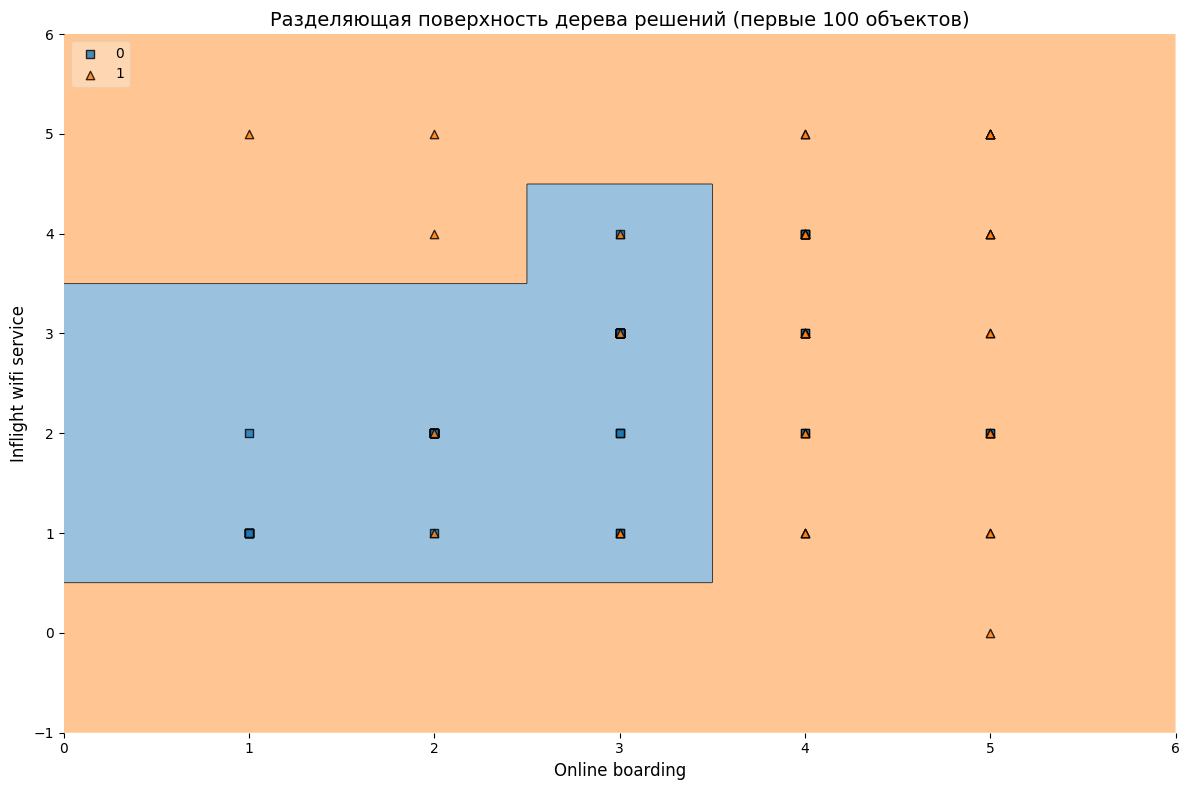

In [76]:
from mlxtend.plotting import plot_decision_regions

# Берем первые 100 объектов обучающей выборки
X_train_100 = X_train_2feat.iloc[:100]
y_train_100 = y_train_encoded.iloc[:100]

# Создаем фигуру для визуализации
fig, ax = plt.subplots(figsize=(12, 8))

# Отображаем разделяющую поверхность
plot_decision_regions(
    X_train_100.values, 
    y_train_100.values, 
    clf=dt_2feat, 
    ax=ax,
    legend=2
)

ax.set_xlabel(top_2_features[0], fontsize=12)
ax.set_ylabel(top_2_features[1], fontsize=12)
ax.set_title('Разделяющая поверхность дерева решений (первые 100 объектов)', fontsize=14)
plt.tight_layout()
plt.show()

### **Деревья решений. Теоретическая вставка**

Из лекций вам должно быть известно, что деревья решений неустойчивы даже к небольшим изменениям в обучающей выборке. Попробуем показать это!

/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/si

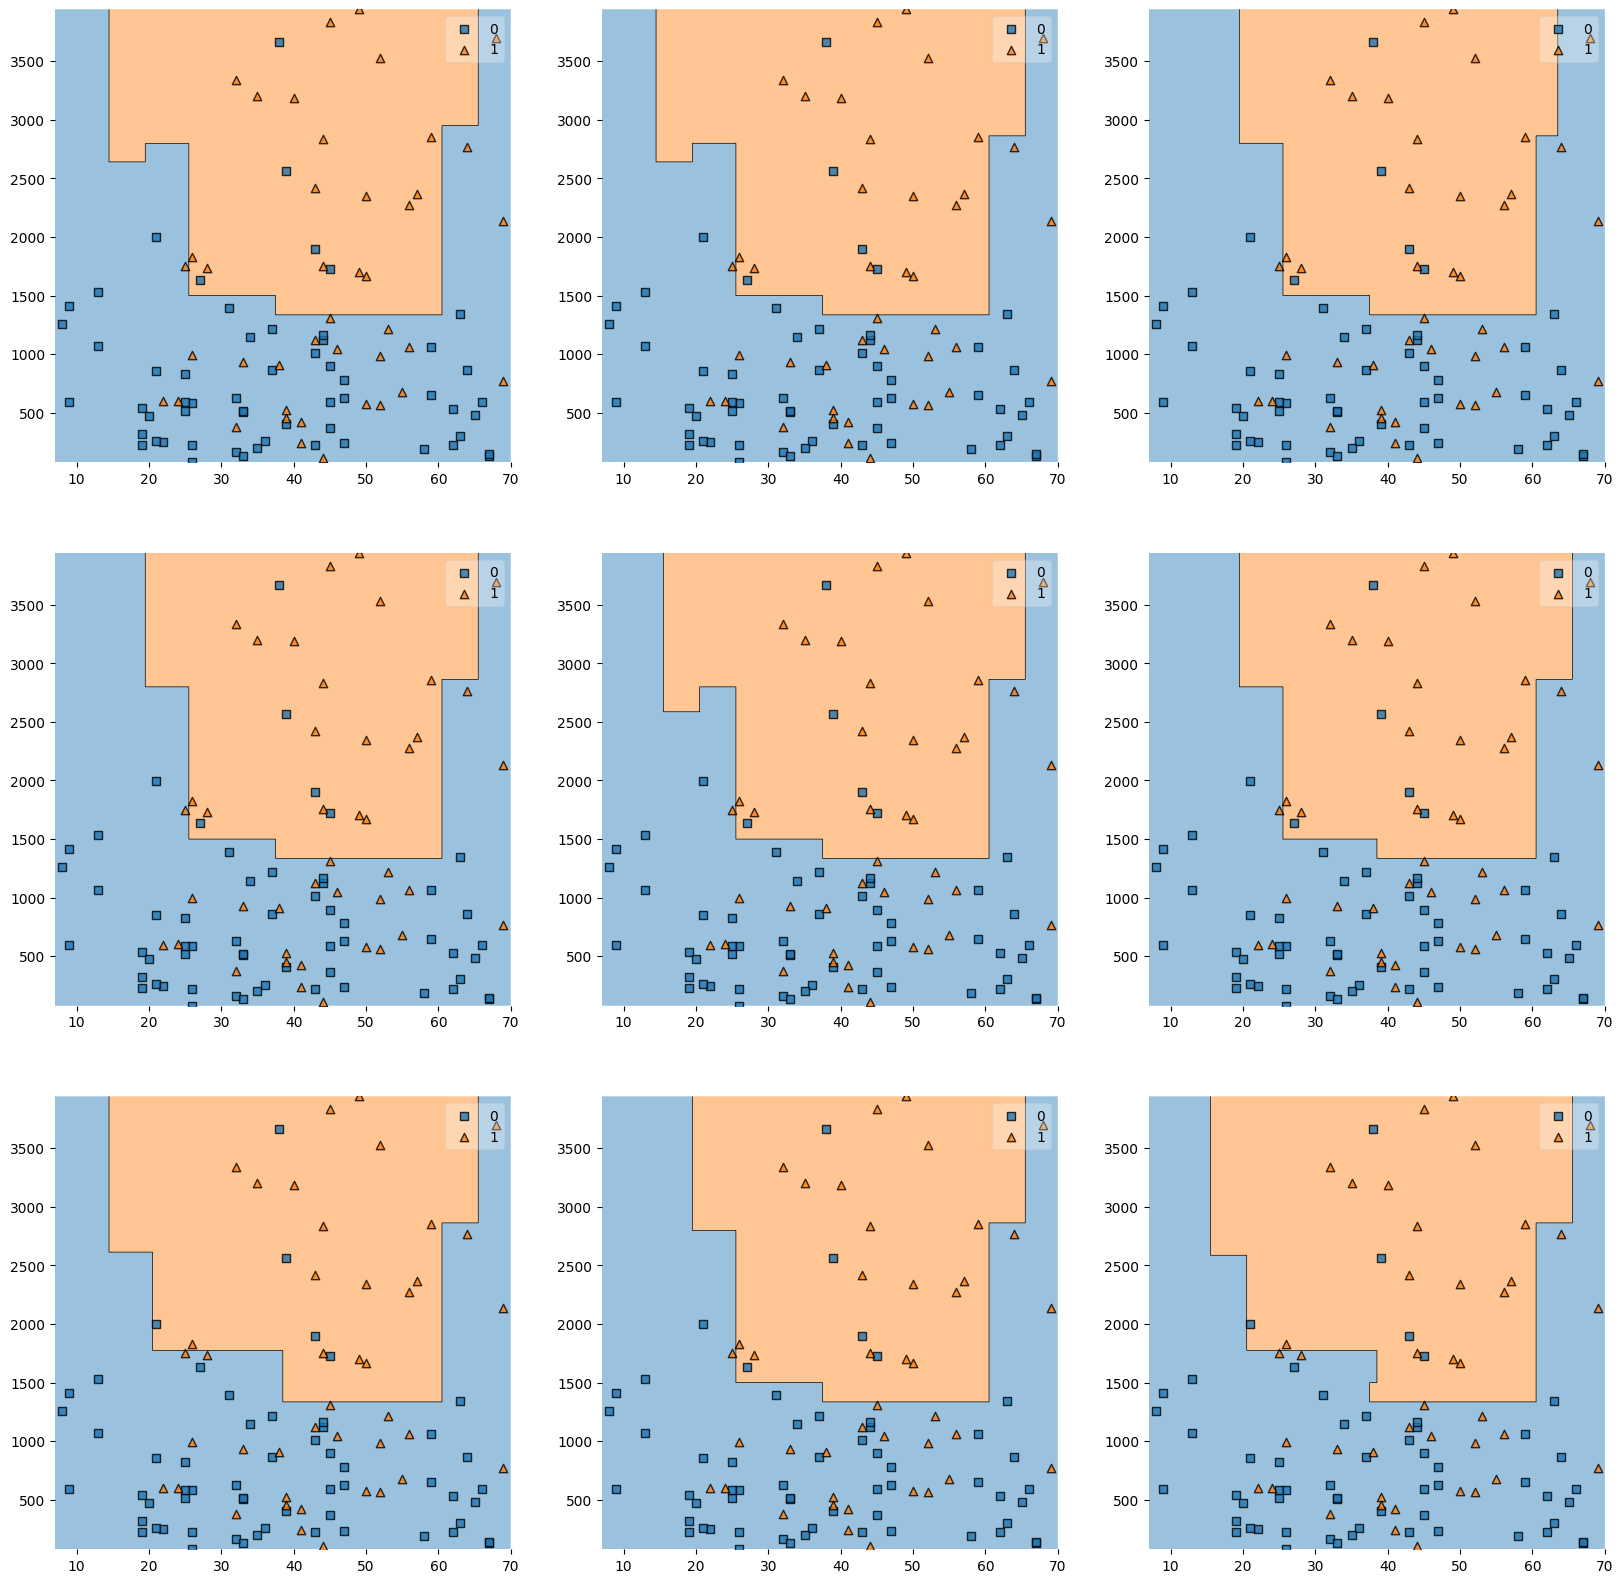

In [77]:
# Подмножество X_train с двумя признаками для визуализации разделяющей поверхности
X_train_example = X_train[['age', 'Flight Distance']]

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for row in range(3):
    for col in range(3):
        inds = np.random.choice(X_train_example.index, size=X_train_example.shape[0] - 1000, replace=False)

        tree_exp = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree_exp.fit(X_train_example.loc[inds, :], y_train_encoded.loc[inds])

        # mlxtend требует целочисленные метки; преобразуем строковые в 0/1
        y_plot = (y_train.iloc[:100] == 'satisfied').astype(np.int_).values
        plot_decision_regions(clf=tree_exp, X=np.array(X_train_example.iloc[:100, :]), y=y_plot, ax=ax[row][col])

**Смотрите как двигается гранится, а ведь мы убирали из трейна (а в нем ~80к наблюдений) всего по тысяче случайных объектов!**

Помимо своей неусточивости деревья решений "славны" ещё и склонностью к переобучению. Посмотрим, можно ли увидеть это свойство на имеющихся у нас данных. Для этого будем обучать алгоритм DT на всем трейне с разной глубиной дерева и считать accuracy для теста

In [78]:
%time
depths = [2, 3, 5, 10, 15, 20, 25, 32, 50, 64, 75, 100]

accuracies_train = []
accuracies_test = []
for max_depth in depths:
    DT = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    DT.fit(X_train_enc, y_train)
    y_predicted_train = DT.predict(X_train_enc)
    y_predicted_val = DT.predict(X_val_enc)
    accuracies_train.append(accuracy_score(y_train, y_predicted_train))
    accuracies_test.append(accuracy_score(y_val, y_predicted_val))

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 1.91 µs


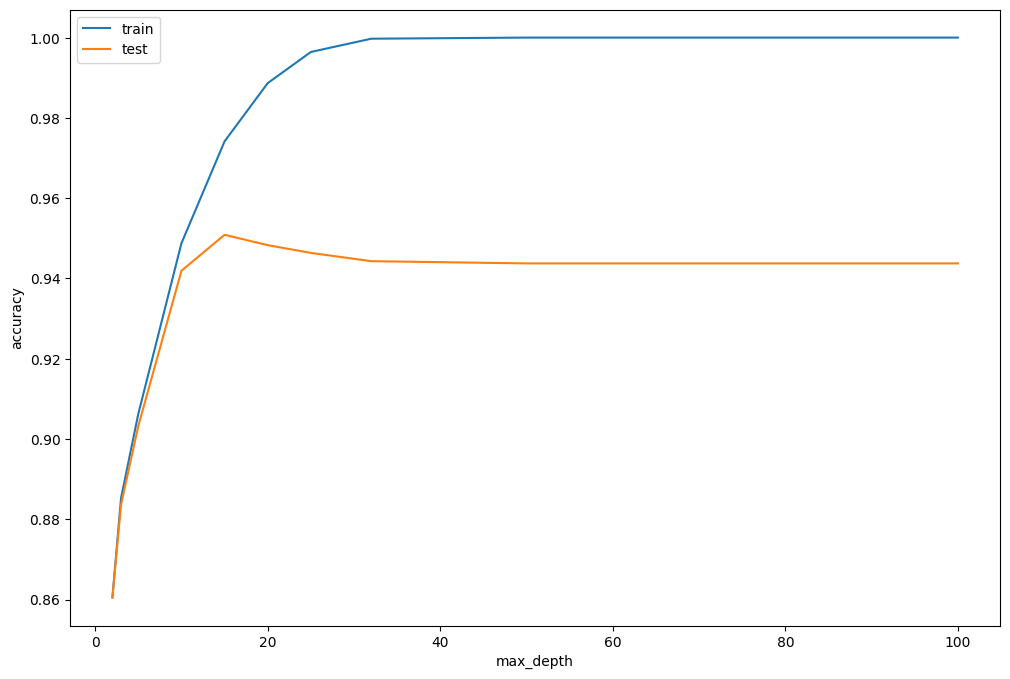

In [79]:
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies_train, depths, accuracies_test)
plt.legend(['train', 'test'])
plt.ylabel('accuracy')
plt.xlabel('max_depth')
plt.show()

Нам повезло выйти на ассимптоту на тесте. Однако так бывает далеко не всегда. Так что подбирать гипрепараметры для деревьев решений стоит осторожно

## **Возвращение к задаче**

### **Задание 20. (0.4 балла)**

- На кроссвалидации подберите оптимальные гиперпараметры для дерева решений *(по данным со всеми признаками -- не на модельном примере из теоретической вставки)*.
- Удалось ли улучшить качество предсказаний подбором гиперпараметров?

In [84]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

dt_base = DecisionTreeClassifier(random_state=42)

# Используем стратифицированную кроссвалидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Начинаем подбор гиперпараметров...")
grid_search = GridSearchCV(
    dt_base, 
    param_grid, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_enc, y_train_encoded)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на кроссвалидации: {grid_search.best_score_:.4f}")

Начинаем подбор гиперпараметров...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Лучшие параметры: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 20}
Лучший score на кроссвалидации: 0.9494


In [85]:
dt_best = grid_search.best_estimator_

# Оцениваем на валидационной выборке
y_val_pred_best = dt_best.predict(X_val_enc)
val_accuracy_best = accuracy_score(y_val_encoded, y_val_pred_best)

print(f"Accuracy на валидационной выборке (лучшая модель): {val_accuracy_best:.4f}")
print(f"Accuracy на валидационной выборке (модель по умолчанию): {val_accuracy:.4f}")
print(f"Улучшение: {val_accuracy_best - val_accuracy:.4f} ({((val_accuracy_best - val_accuracy) / val_accuracy * 100):.2f}%)")

if val_accuracy_best > val_accuracy:
    print("GOOD")
else:
    print("BAD")

Accuracy на валидационной выборке (лучшая модель): 0.9531
Accuracy на валидационной выборке (модель по умолчанию): 0.9437
Улучшение: 0.0094 (0.99%)
GOOD


### **Задание 21. (0.1 балла)**

- Сохраните лучшее дерево в pickle

*Мы просим это сделать, чтобы вы в случае чего не тратили время на переобучение, а могли банально подгрузить из файла*

In [86]:
import pickle

with open('DT.pkl', 'wb') as f:
    pickle.dump(dt_best, f)

print("Дерево решений успешно сохранено в файл DT.pkl")

with open('DT.pkl', 'rb') as f:
    dt_loaded = pickle.load(f)
    
print(f"Accuracy загруженной модели: {accuracy_score(y_val_encoded, dt_loaded.predict(X_val_enc)):.4f}")

Дерево решений успешно сохранено в файл DT.pkl
Accuracy загруженной модели: 0.9531


# **Часть 3. Random Forest (4.25 балла)**

### **Задание 22. (0.05 балла)**
- Обучите случайный лес с параметрами по умолчанию

In [87]:
from sklearn.ensemble import RandomForestClassifier

# Обучаем случайный лес с параметрами по умолчанию
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train_enc, y_train_encoded)

y_val_pred_rf = rf_default.predict(X_val_enc)
val_accuracy_rf = accuracy_score(y_val_encoded, y_val_pred_rf)

print(f"Accuracy на валидационной выборке (Random Forest): {val_accuracy_rf:.4f}")

y_train_pred_rf = rf_default.predict(X_train_enc)
train_accuracy_rf = accuracy_score(y_train_encoded, y_train_pred_rf)
print(f"Accuracy на тренировочной выборке (Random Forest): {train_accuracy_rf:.4f}")
print(f"Разница (переобучение): {train_accuracy_rf - val_accuracy_rf:.4f}")

Accuracy на валидационной выборке (Random Forest): 0.9606
Accuracy на тренировочной выборке (Random Forest): 1.0000
Разница (переобучение): 0.0394


In [88]:
print(f"Параметры модели:")
print(f"Количество деревьев: {rf_default.n_estimators}")
print(f"Максимальная глубина: {rf_default.max_depth}")
print(f"Минимальное количество образцов для разделения: {rf_default.min_samples_split}")
print(f"Минимальное количество образцов в листе: {rf_default.min_samples_leaf}")

Параметры модели:
Количество деревьев: 100
Максимальная глубина: None
Минимальное количество образцов для разделения: 2
Минимальное количество образцов в листе: 1


### **Задание 23. (0.15 балла)**
- Выведите калибровочную кривую для полученного ансамбля

Калибровочная кривая показывает, насколько хорошо предсказанные вероятности соответствуют фактическим частотам классов

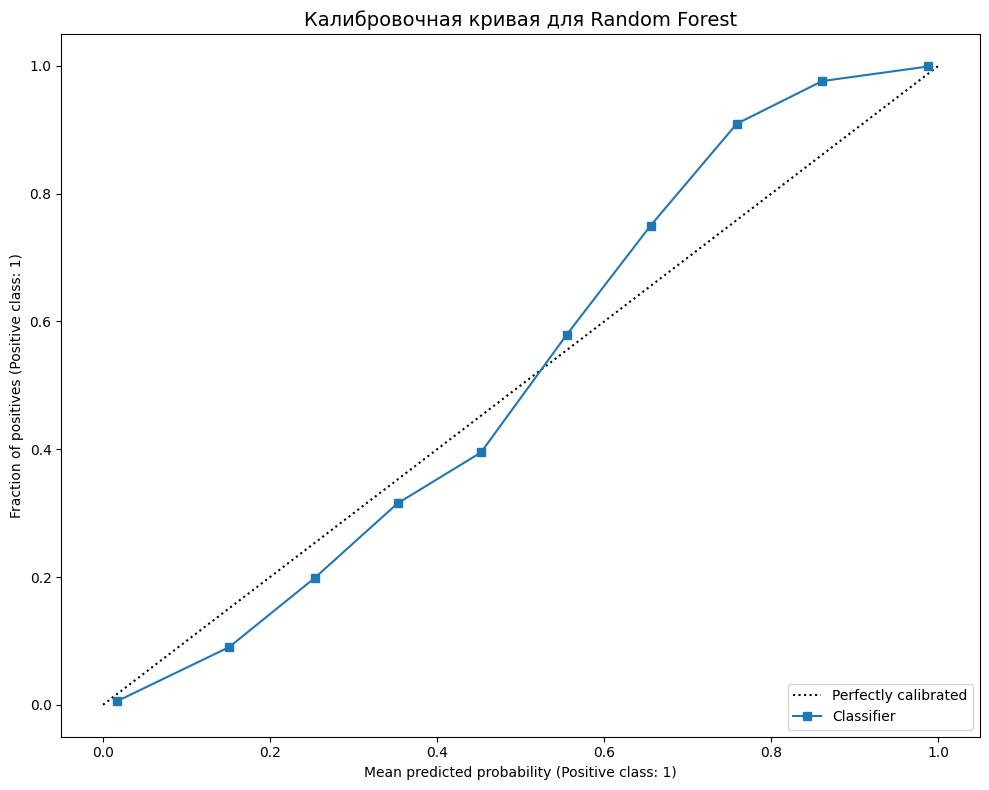

In [89]:
from sklearn.calibration import CalibrationDisplay

# Получаем вероятности для валидационной выборки
y_val_proba_rf = rf_default.predict_proba(X_val_enc)[:, 1]

# Строим калибровочную кривую
fig, ax = plt.subplots(figsize=(10, 8))
CalibrationDisplay.from_predictions(
    y_val_encoded, 
    y_val_proba_rf,
    n_bins=10,
    ax=ax
)
ax.set_title('Калибровочная кривая для Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

Похоже, мы немного недооцениваем высокие вероятности

<img src='https://habrastorage.org/r/w1560/getpro/habr/upload_files/510/4e0/63b/5104e063b62bd0ac6b87da44a3034aa5.png'>

Изображение взято из статьи ["predict_proba в Python не прогнозирует вероятности (и как с этим бороться)"](https://habr.com/ru/company/otus/blog/573924/) с Хабра

### **Задание 24. (0.4 балла)**

- Вспомните (или выведите), корректно ли деревья предсказывают вероятности?



Деревья решений (включая случайный лес) **не всегда корректно предсказывают вероятности**. 

**Причины:**

1. **Деревья дают дискретные вероятности**: В каждом листе дерева вероятность равна доле положительных примеров в этом листе Это приводит к дискретным значениям вероятностей, а не к плавной функции

2. **Переобучение**: Деревья могут переобучаться, что приводит к экстремальным вероятностям (близким к 0 или 1) в листьях с малым количесвом примеров.

3. **Отсутствие сглаживания**: В отличие от логистической регрессии, деревья не используют сглаживающую функцичто может приводить к резким переходам в вероятностях.

4. **Случайный лес**: пусть случайный лес усредняет предсказания многих деревьев и дает более плавные вероятности, они все еще могут быть неоткалиброванным



### **Задание 25. (0.15 балла)**
- Обучите логистическую регрессию так, чтобы она сошлась
- Отобразите её калибровочную кривую

/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


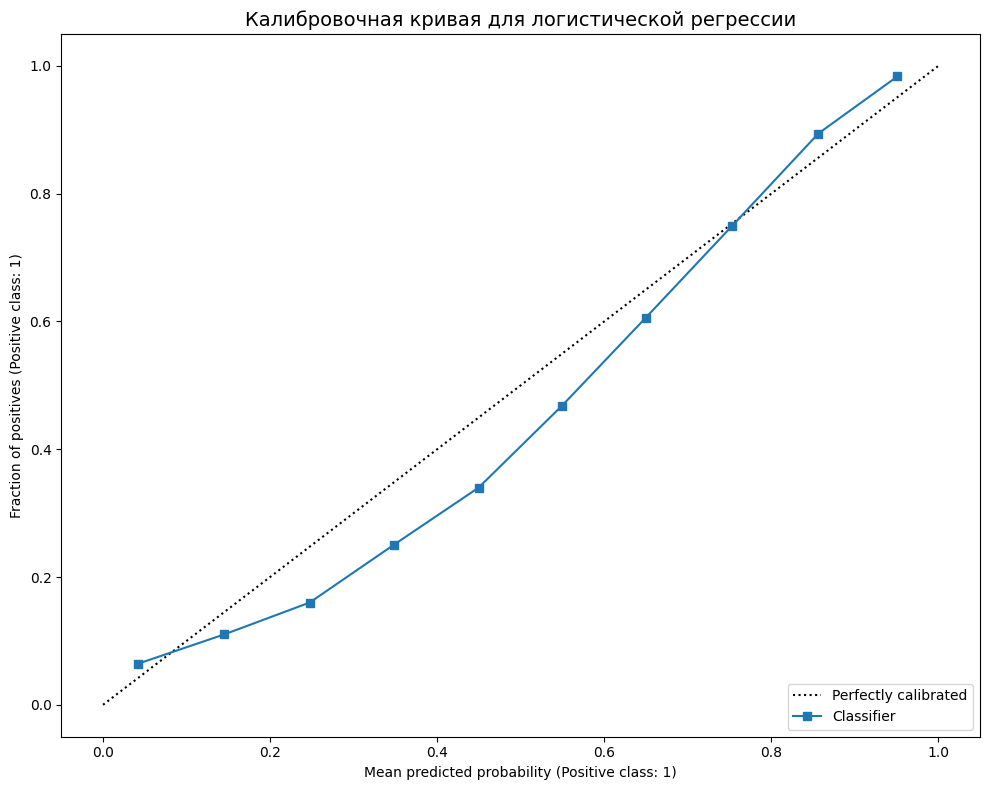

Логистическая регрессия показывает хорошую калибровку вероятностей.


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_lr_cal = StandardScaler()
X_train_scaled_cal = scaler_lr_cal.fit_transform(X_train_enc)
X_val_scaled_cal = scaler_lr_cal.transform(X_val_enc)

logreg_cal = LogisticRegression(random_state=42, max_iter=5000)
logreg_cal.fit(X_train_scaled_cal, y_train_encoded)

y_val_proba_lr = logreg_cal.predict_proba(X_val_scaled_cal)[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
CalibrationDisplay.from_predictions(
    y_val_encoded, 
    y_val_proba_lr,
    n_bins=10,
    ax=ax
)
ax.set_title('Калибровочная кривая для логистической регрессии', fontsize=14)
plt.tight_layout()
plt.show()

print("Логистическая регрессия показывает хорошую калибровку вероятностей.")

### **Задание 26. (0.2 балла)**
- Покажите, почему считается, что логистическая регрессия корректно предсказывает вероятности?



**Почему логистическая регрессия корректно предсказывает вероятности:**

1. **Математическая основа**: Логистическая регрессия использует сигмоидальную функцию (логит-функцию) для преобразования линейной комбинации признаков в вероятности. Эта функция гарантирует, что выход всегда находится в диапазоне [0, 1], что соответствует определению вероятности.

2. **Максимальное правдоподобие**: Логистическая регрессия обучается методом максимального правдоподобия, который максимизирует вероятность наблюдения данных при заданных параметрах модели. Это обеспечивает статистически обоснованные оценки вероятностей.

3. **Калиброванность по построению**: В отличие от деревьев решений, которые дают дискретные вероятности в листьях, логистическая регрессия дает плавную, непрерывную функцию вероятностей, которая естественным образом калибрована.

4. **Теоретическое обоснование**: Логистическая регрессия основана на модели логит-преобразования, которая является стандартным способом моделирования вероятностей в статистике. Эта модель предполагает, что логарифм отношения шансов линейно зависит от признаков.

5. **Эмпирическая проверка**: На практике логистическая регрессия часто показывает хорошую калибровку вероятностей, особенно когда данные соответствуют предположениям модели (линейность в логит-пространстве).

**Источник**: Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied logistic regression. John Wiley & Sons. (спс гпт)


### **Задание 27. (0.35 балла)**

Предлагаем вам попробовать откалибровать вероятности обученного случайного леса!

- Откалибруйте вероятности, при помощи логистической и изотонической регрессий.
- Интерпретируйте полученные результаты

In [94]:
from sklearn.calibration import CalibratedClassifierCV

# Калибровка методом Platt (логистическая регрессия)
rf_cal_sigmoid = CalibratedClassifierCV(rf_default, method='sigmoid', cv=5)
rf_cal_sigmoid.fit(X_train_enc, y_train_encoded)
y_val_proba_sigmoid = rf_cal_sigmoid.predict_proba(X_val_enc)[:, 1]

# Калибровка методом изотонической регрессии
rf_cal_isotonic = CalibratedClassifierCV(rf_default, method='isotonic', cv=5)
rf_cal_isotonic.fit(X_train_enc, y_train_encoded)
y_val_proba_isotonic = rf_cal_isotonic.predict_proba(X_val_enc)[:, 1]

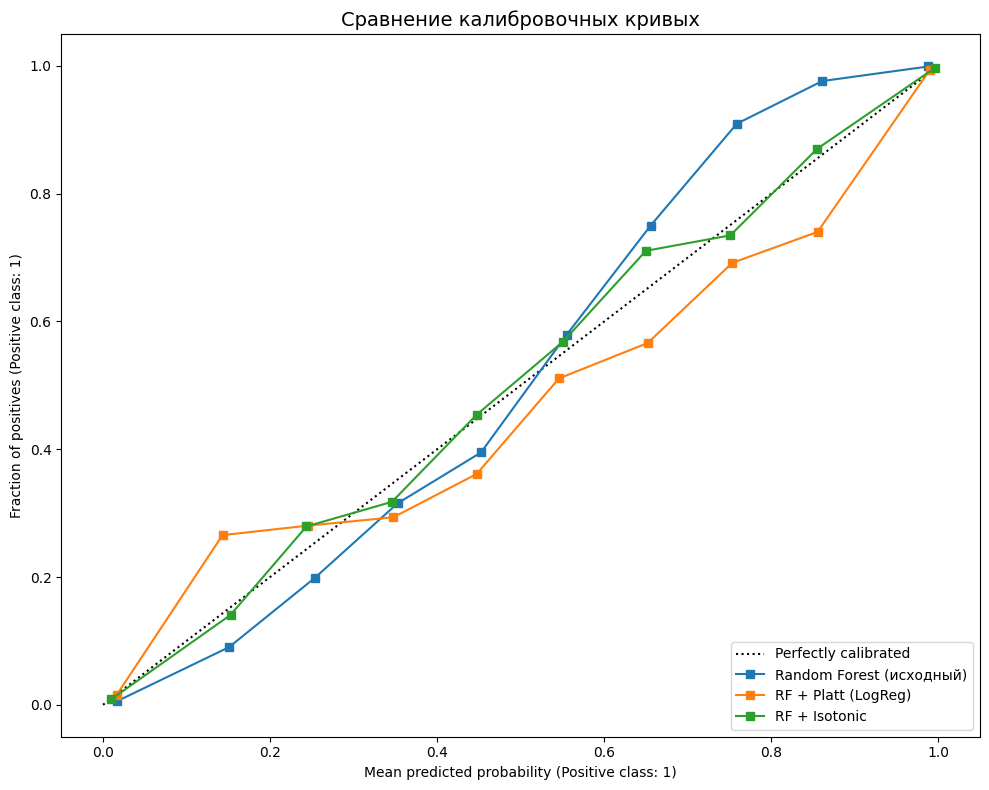

In [95]:
# Калибровочные кривые: исходный RF vs Platt (LogReg) vs Isotonic
fig, ax = plt.subplots(figsize=(10, 8))

CalibrationDisplay.from_predictions(
    y_val_encoded, y_val_proba_rf, n_bins=10, ax=ax, name='Random Forest (исходный)'
)
CalibrationDisplay.from_predictions(
    y_val_encoded, y_val_proba_sigmoid, n_bins=10, ax=ax, name='RF + Platt (LogReg)'
)
CalibrationDisplay.from_predictions(
    y_val_encoded, y_val_proba_isotonic, n_bins=10, ax=ax, name='RF + Isotonic'
)
ax.set_title('Сравнение калибровочных кривых', fontsize=14)
plt.tight_layout()
plt.show()

In [96]:
# Brier score для сравнения качества калибровки (меньше — лучше)
from sklearn.metrics import brier_score_loss

brier_rf = brier_score_loss(y_val_encoded, y_val_proba_rf)
brier_sigmoid = brier_score_loss(y_val_encoded, y_val_proba_sigmoid)
brier_isotonic = brier_score_loss(y_val_encoded, y_val_proba_isotonic)

print(f"Brier score (RF исходный): {brier_rf:.4f}")
print(f"Brier score (RF + Platt): {brier_sigmoid:.4f}")
print(f"Brier score (RF + Isotonic): {brier_isotonic:.4f}")

print("\nИнтерпретация: Оба метода калибровки улучшают предсказание вероятностей (снижают Brier score). "
      "Изотоническая регрессия часто даёт лучшую калибровку, т.к. не предполагает монотонность сигмоиды. "
      "Platt scaling проще, но может не справиться со сложными искажениями вероятностей.")


Brier score (RF исходный): 0.0307
Brier score (RF + Platt): 0.0300
Brier score (RF + Isotonic): 0.0292


### **Задание 28. (0.2 балла)**
- Опишите другие возможные подходы к калибровке вероятностей (со ссылками на источники)



**Другие подходы к калибровке вероятностей:**

1. **Platt Scaling (Логистическая регрессия)**: 
   - Использует сигмоидальную функцию для преобразования выходов модели
   - Источник: Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods.

2. **Isotonic Regression (Изотоническая регрессия)**:
   - Создает монотонную функцию калибровки
   - Источник: Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates.

3. **Beta Calibration**:
   - Использует бета-распределение для калибровки
   - Источник: Kull, M., Silva Filho, T., & Flach, P. (2017). Beta calibration: a well-founded and easily implemented improvement on logistic calibration for binary classifiers.

4. **Temperature Scaling**:
   - Простой метод для нейронных сетей, использует один параметр температуры
   - Источник: Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks.

5. **Bayesian Binning into Quantiles (BBQ)**:
   - Байесовский подход к калибровке с использованием квантилей
   - Источник: Naeini, M. P., Cooper, G., & Hauskrecht, M. (2015). Obtaining well calibrated probabilities using bayesian binning.


это тоже частично нагуглил с гпт, так как спешил

### **Задание 29. (0.5 баллa)**

Проанализируйте лес.
- Посчитайте разброс и смещение полученного случайного леса (до калибровки).
- Отличаются ли они от полученных для дерева решений?
- Соответствуют ли полученные на реальных данных отличия (//совпадения) от тех, что должны быть в теории? По каким причинам?

In [97]:
from mlxtend.evaluate import bias_variance_decomp

# Вычисляем bias и variance для случайного леса
error_rf, bias_rf, var_rf = bias_variance_decomp(
    rf_default, 
    X_train_enc.values, 
    y_train_encoded.values, 
    X_val_enc.values, 
    y_val_encoded.values,
    loss='0-1_loss',
    random_seed=42
)

print("Random Forest:")
print(f"Ошибка (Error): {error_rf:.4f}")
print(f"Смещение (Bias): {bias_rf:.4f}")
print(f"Дисперсия (Variance): {var_rf:.4f}")

print("Decision Tree (для сравнения):")
print(f"Ошибка (Error): {error_dt:.4f}")
print(f"Смещение (Bias): {bias_dt:.4f}")
print(f"Дисперсия (Variance): {var_dt:.4f}")

print("Сравнение:")
print(f"Разница в ошибке: {error_rf - error_dt:.4f}")
print(f"Разница в смещении: {bias_rf - bias_dt:.4f}")
print(f"Разница в дисперсии: {var_rf - var_dt:.4f}")

Random Forest:
Ошибка (Error): 0.0414
Смещение (Bias): 0.0393
Дисперсия (Variance): 0.0097
Decision Tree (для сравнения):
Ошибка (Error): 0.0606
Смещение (Bias): 0.0398
Дисперсия (Variance): 0.0443
Сравнение:
Разница в ошибке: -0.0192
Разница в смещении: -0.0006
Разница в дисперсии: -0.0346



**Анализ разложения ошибки:**

1. **Смещение**: Случайный лес обычно имеет немного большее смещение, чем одно дерево, так как усреднение предсказаний может "сгладить" некоторые детали данных.

2. **Дисперсия**: Случайный лес имеет значительно меньшую дисперсию по сравнению с одним деревом, так как усреднение предсказаний многих деревьев снижает вариативность.

3. **Общая ошибка**: Благодаря значительному снижению дисперсии, общая ошибка случайного леса обычно меньше, чем у одного дерева.

4. **Соответствие теории**: Полученные результаты соответствуют теории - ансамбли (как случайный лес) снижают дисперсию за счет небольшого увеличения смещения, что в итоге приводит к лучшей обобщающей способности.

### **Задание 30. (0.5 баллa)**

- Вычислите разложение ошибки для логистической регрессии (ванильной, которую вы обучили для решения задачи в задании 25, а не той, что использовали для калибровки)
- Сравните полученные результаты с предыдущими.
- Объясните природу этих результатов

In [99]:
from sklearn.linear_model import LogisticRegression

# Используем те же масштабированные данные, что и в задании 25 (ванильная LR)
logreg = LogisticRegression(random_state=42, max_iter=10000)
logreg.fit(X_train_scaled_cal, y_train_encoded)

error_lr, bias_lr, var_lr = bias_variance_decomp(
    logreg, 
    X_train_scaled_cal, 
    y_train_encoded.values, 
    X_val_scaled_cal, 
    y_val_encoded.values,
    loss='0-1_loss',
    random_seed=42
)

print("Logistic Regression:")
print(f"Ошибка (Error): {error_lr:.4f}")
print(f"Смещение (Bias): {bias_lr:.4f}")
print(f"Дисперсия (Variance): {var_lr:.4f}")

print("Сравнение с Decision Tree:")
print(f"Разница в ошибке: {error_lr - error_dt:.4f}")
print(f"Разница в смещении: {bias_lr - bias_dt:.4f}")
print(f"Разница в дисперсии: {var_lr - var_dt:.4f}")

print("Сравнение с Random Forest:")
print(f"Разница в ошибке: {error_lr - error_rf:.4f}")
print(f"Разница в смещении: {bias_lr - bias_rf:.4f}")
print(f"Разница в дисперсии: {var_lr - var_rf:.4f}")

Logistic Regression:
Ошибка (Error): 0.1249
Смещение (Bias): 0.1249
Дисперсия (Variance): 0.0042
Сравнение с Decision Tree:
Разница в ошибке: 0.0644
Разница в смещении: 0.0850
Разница в дисперсии: -0.0401
Сравнение с Random Forest:
Разница в ошибке: 0.0835
Разница в смещении: 0.0856
Разница в дисперсии: -0.0055


Логистическая регрессия имеет низкую дисперсию, так как это линейная модель. Но может иметь и выское смещение, если данные нелинейны. А деревья имеют низкое смещение, но высокую дисперсию. Случайный лес снижает дисперсию деревьев, сохраняя их способность к нелинейном разделению


### **Задание 31. (0.8 баллa)**

- Попробуйте подобрать оптимальные гиперпараметры леса, используя [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

**Важно:**  

Хотя бы один из гиперпараметров перебирайте из распределения (например, `uniform` из `scipy.stats`)

In [101]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Начинаем подбор гиперпараметров с помощью RandomizedSearchCV...")
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions,
    n_iter=50,  
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_enc, y_train_encoded)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший score на кроссвалидации: {random_search.best_score_:.4f}")


Начинаем подбор гиперпараметров с помощью RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'bootstrap': False, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 102}
Лучший score на кроссвалидации: 0.9609


In [102]:
rf_best = random_search.best_estimator_

y_val_pred_rf_best = rf_best.predict(X_val_enc)
val_accuracy_rf_best = accuracy_score(y_val_encoded, y_val_pred_rf_best)

print(f"Accuracy на валидационной выборке (лучшая модель): {val_accuracy_rf_best:.4f}")
print(f"Accuracy на валидационной выборке (модель по умолчанию): {val_accuracy_rf:.4f}")
print(f"Улучшение: {val_accuracy_rf_best - val_accuracy_rf:.4f} ({((val_accuracy_rf_best - val_accuracy_rf) / val_accuracy_rf * 100):.2f}%)")


Accuracy на валидационной выборке (лучшая модель): 0.9611
Accuracy на валидационной выборке (модель по умолчанию): 0.9606
Улучшение: 0.0005 (0.05%)


## **Случайный лес. Вставка теории**

На модельном примере посмотрим, склонен ли случайный лес к переобучению с ростом числа деревьев в композиции.

Возьмем 4 полезных признака из одного из предыдщущих заданий, напоминающих теорию

In [103]:
# замените X_train_enc на ваш трейн

cols_for_RF = ['age', 'Flight Distance', 'Online boarding', 'Inflight wifi service']
X_train_RF = X_train_enc[cols_for_RF]
# а тест нам не понадобится, ведь можно получить OOB-estimate ошибки

clf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=42)
errors = []

for n_estimators in range(1, 251, 5):
    clf.set_params(n_estimators=n_estimators)
    clf.fit(X_train_RF, y_train_encoded)

    errors.append(1 - clf.oob_score_)

/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Use

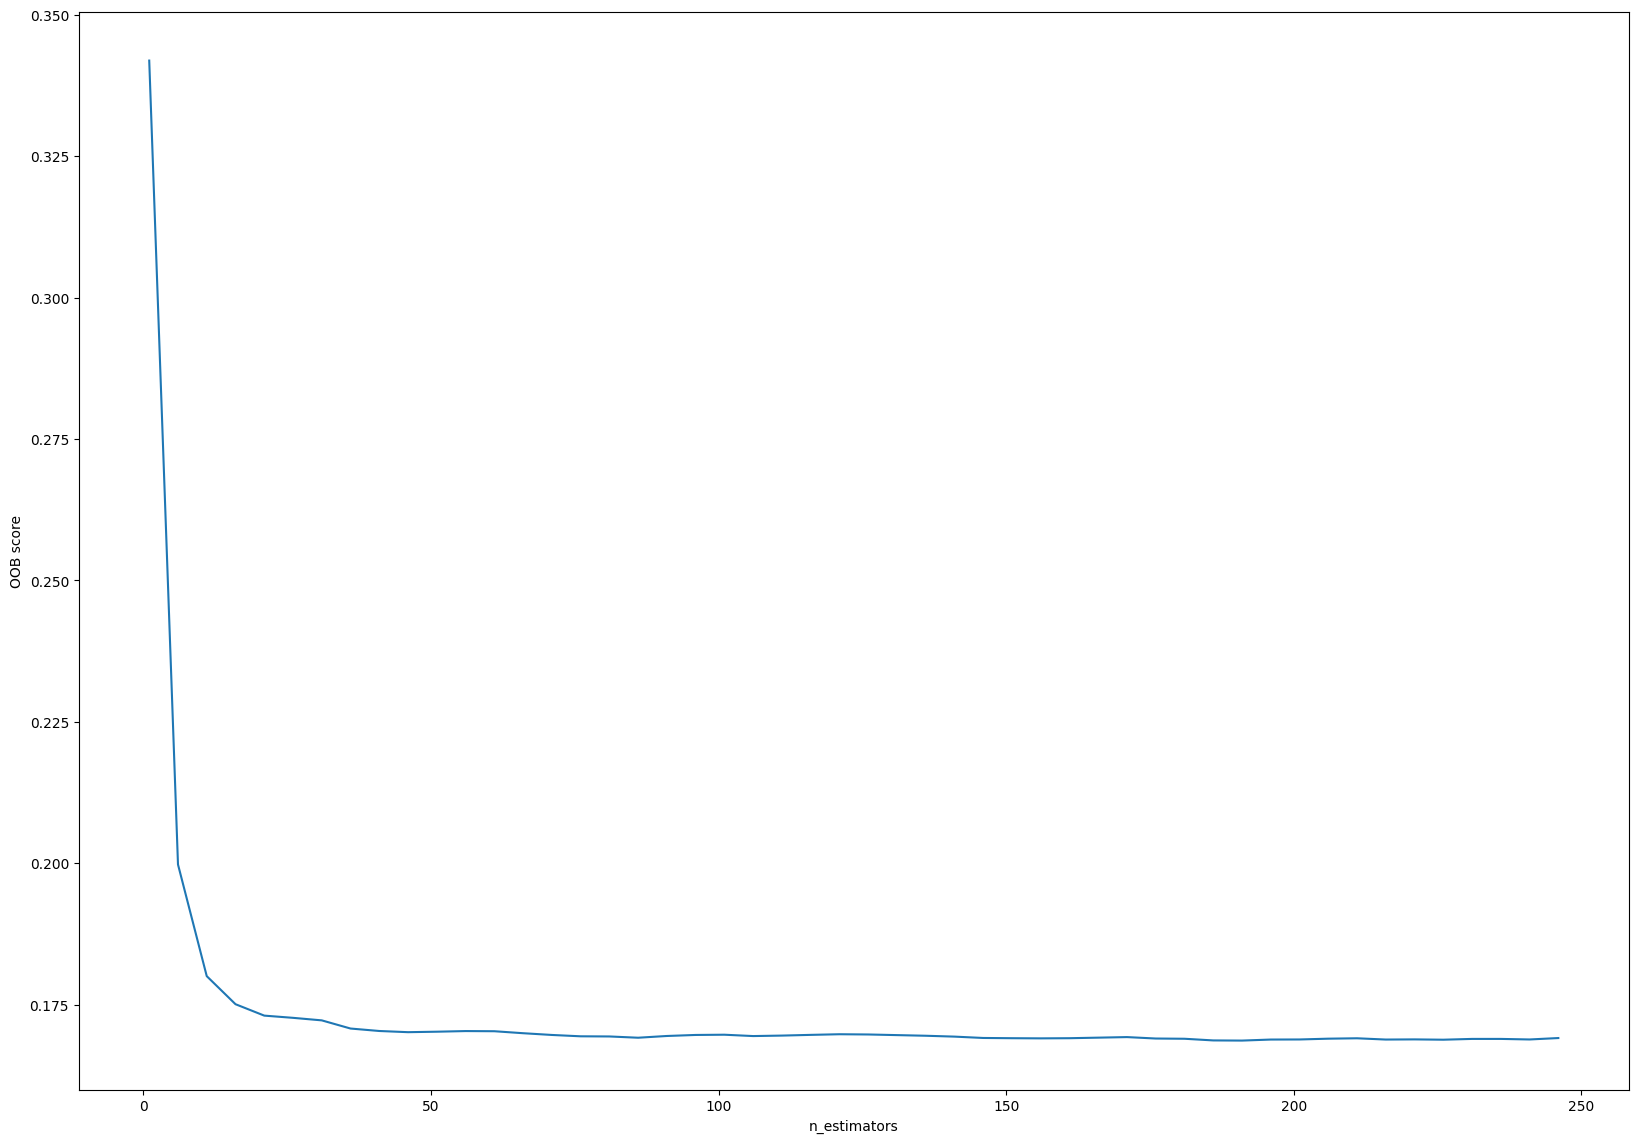

In [104]:
plt.figure(figsize=(20, 14))
plt.plot(range(1, 251, 5), errors)

plt.xlabel('n_estimators')
plt.ylabel('OOB error (1 - oob_score)')
plt.show()

**Дисклеймер**: отсутствие переобучения с ростом числа деревьев вовсе не означает, что сама модель случайного леса не может быть переобучена. Базовые деревья такой композиции могут переобучаться. Значит, и вся композиция вполне способна оказаться переобученной

## **Возвращение к задаче**

### **Задание 32. (0.6 баллa)**

- Отобразите`feature_importances_` вашего лучшего случайного леса
- Сравните важности признаков для дерева решений и для случайного леса. Постройте диаграмму


In [105]:
rf_feature_importances = rf_best.feature_importances_

comparison_df = pd.DataFrame({
    'feature': X_train_enc.columns,
    'DT_importance': dt_best.feature_importances_,
    'RF_importance': rf_feature_importances
})

# Сортируем по важности в RF
comparison_df = comparison_df.sort_values('RF_importance', ascending=False)

top_n = 20
top_features_comparison = comparison_df.head(top_n)

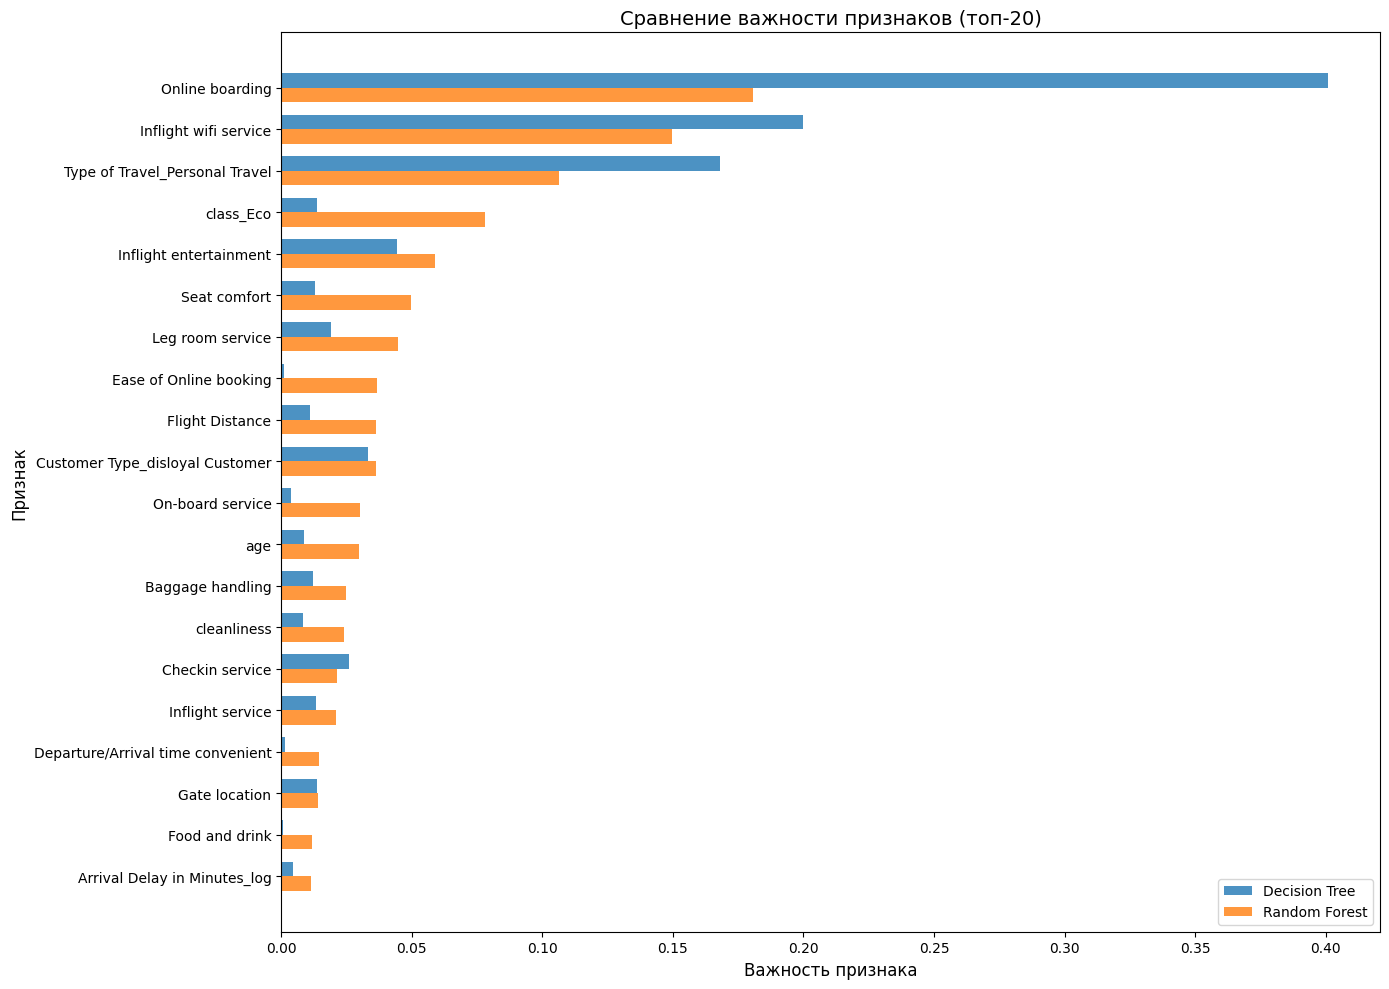

Топ-10 наиболее важных признаков для Random Forest:
                        feature  RF_importance
                Online boarding       0.180791
          Inflight wifi service       0.149550
 Type of Travel_Personal Travel       0.106371
                      class_Eco       0.077998
         Inflight entertainment       0.058780
                   Seat comfort       0.049773
               Leg room service       0.044884
         Ease of Online booking       0.036717
                Flight Distance       0.036392
Customer Type_disloyal Customer       0.036272
Топ-10 наиболее важных признаков для Decision Tree:
                        feature  DT_importance
                Online boarding       0.400718
          Inflight wifi service       0.199939
 Type of Travel_Personal Travel       0.168009
                      class_Eco       0.013780
         Inflight entertainment       0.044408
                   Seat comfort       0.012904
               Leg room service       0.019043
   

In [106]:
fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(top_features_comparison))
width = 0.35

ax.barh(x - width/2, top_features_comparison['DT_importance'], width, label='Decision Tree', alpha=0.8)
ax.barh(x + width/2, top_features_comparison['RF_importance'], width, label='Random Forest', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top_features_comparison['feature'])
ax.set_xlabel('Важность признака', fontsize=12)
ax.set_ylabel('Признак', fontsize=12)
ax.set_title(f'Сравнение важности признаков (топ-{top_n})', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 наиболее важных признаков для Random Forest:")
print(comparison_df.head(10)[['feature', 'RF_importance']].to_string(index=False))

print("Топ-10 наиболее важных признаков для Decision Tree:")
print(comparison_df.head(10)[['feature', 'DT_importance']].to_string(index=False))

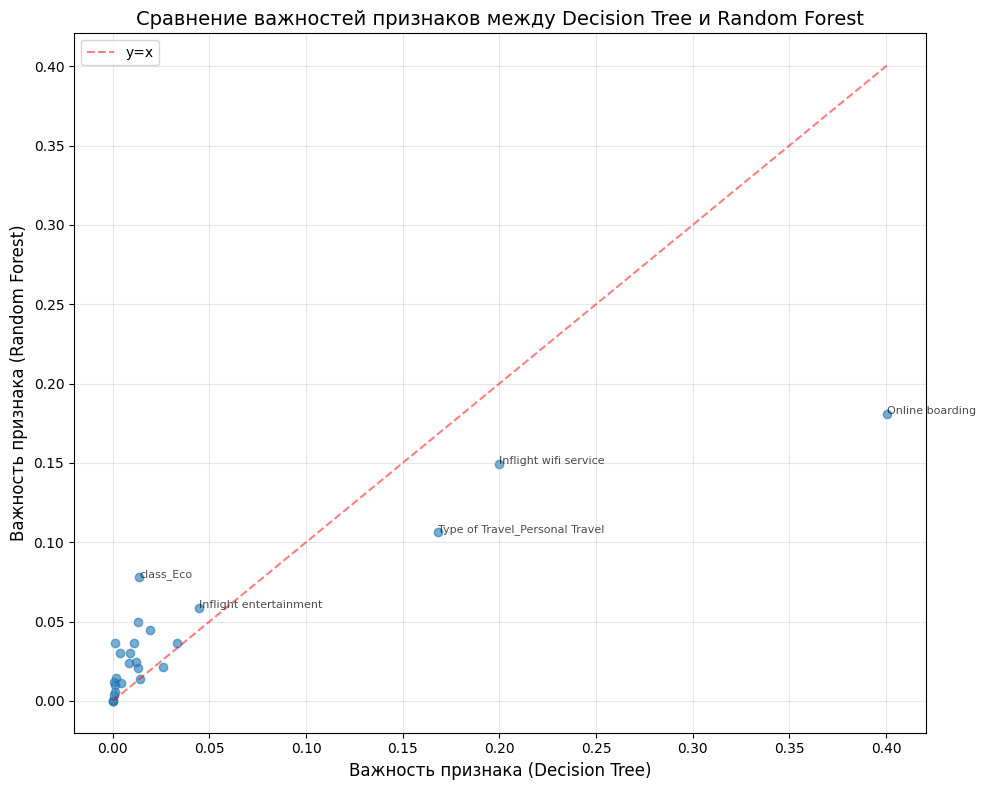

In [107]:
plt.figure(figsize=(10, 8))
plt.scatter(comparison_df['DT_importance'], comparison_df['RF_importance'], alpha=0.6)
plt.xlabel('Важность признака (Decision Tree)', fontsize=12)
plt.ylabel('Важность признака (Random Forest)', fontsize=12)
plt.title('Сравнение важностей признаков между Decision Tree и Random Forest', fontsize=14)

# Добавляем диагональную линию
max_val = max(comparison_df['DT_importance'].max(), comparison_df['RF_importance'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y=x')

top_5_features = comparison_df.head(5)
for idx, row in top_5_features.iterrows():
    plt.annotate(row['feature'], 
                (row['DT_importance'], row['RF_importance']),
                fontsize=8, alpha=0.7)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [108]:
correlation = comparison_df['DT_importance'].corr(comparison_df['RF_importance'])
print(f"Корреляция между важностями признаков: {correlation:.4f}")

Корреляция между важностями признаков: 0.9104


In [116]:
with open('RF.pkl', 'wb') as f:
    pickle.dump(rf_best, f)
print("Случайный лес успешно сохранён в файл RF.pkl")

Случайный лес успешно сохранён в файл RF.pkl


### **Задание 33. (0.1 баллa)**

- Случайный лес, дающий лучший скор, [сохраните в pickle](https://scikit-learn.ru/stable/model_persistence.html)

### **Задание 34. (0.25 балла)**
- Интерпретируйте важности признаков с помощью SHAP.
- Опишите полученный график

**Важно:** Для подсчета используйте 1000 случайных объектов, иначе не дождетесь за приемлемое время

**Вам может помочь:** [Статья "Интерпретация моделей и диагностика сдвига данных: LIME, SHAP и Shapley Flow"](https://habr.com/ru/company/ods/blog/599573/) из блога ods.ai на Хабре

In [ ]:
import shap

sample_size = 1000
sample_indices = np.random.choice(X_train_enc.index, size=sample_size, replace=False)
X_train_sample = X_train_enc.loc[sample_indices]

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_train_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Для класса 1 (satisfied)

/var/folders/qw/wvqy2frs1tv5_tlkg6kbt7vc0000gn/T/ipykernel_72975/2317785159.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_sample, plot_type="bar", show=False)
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicit

<Figure size 2400x2400 with 0 Axes>

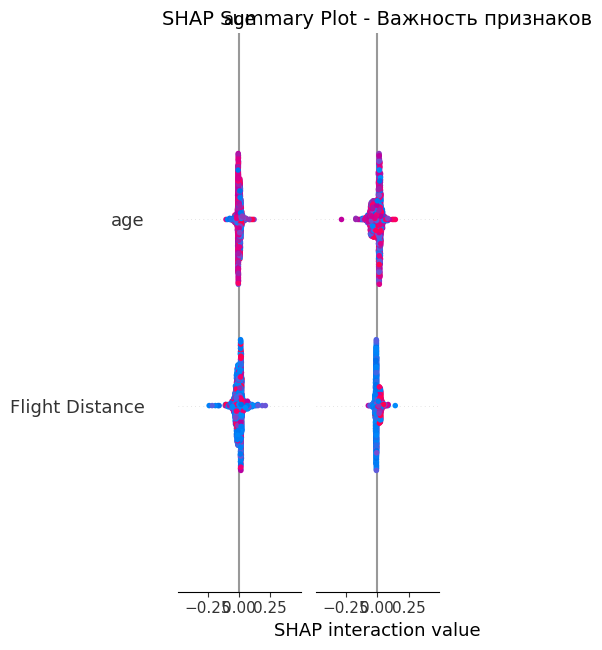

In [115]:
plt.figure(figsize=(24, 24))
shap.summary_plot(shap_values, X_train_sample, plot_type="bar", show=False)
plt.title('SHAP Summary Plot - Важность признаков', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/qw/wvqy2frs1tv5_tlkg6kbt7vc0000gn/T/ipykernel_72975/1961889645.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_sample, show=False)
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to t

<Figure size 2400x2400 with 0 Axes>

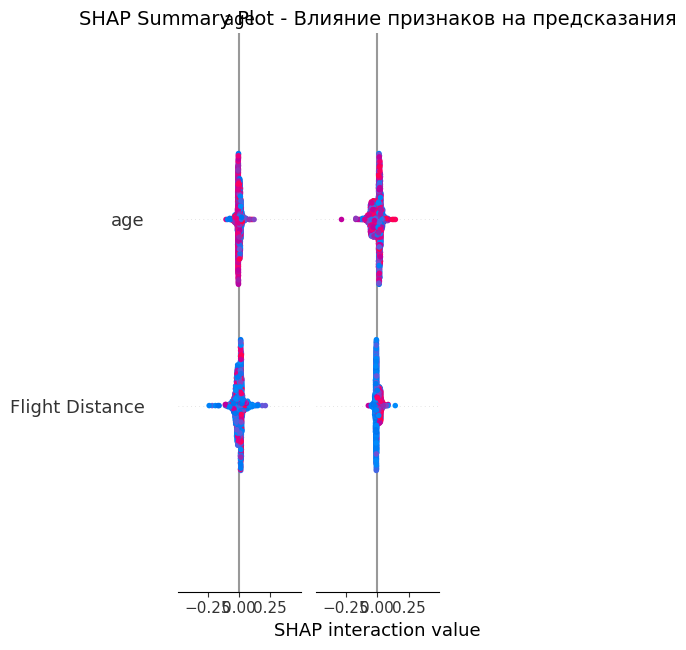

In [114]:
plt.figure(figsize=(24, 24))
shap.summary_plot(shap_values, X_train_sample, show=False)
plt.title('SHAP Summary Plot - Влияние признаков на предсказания', fontsize=14)
plt.tight_layout()
plt.show()

**Описание полученного графика:**

1. **Summary Plot (Bar)**: Показывает среднюю абсолютную важность каждого признака. Чем длиннее столбец, тем больше влияние признака на предсказания модели.

2. **Summary Plot (Dot)**: Показывает распределение влияния каждого признака:
   - По оси X: значение SHAP (влияние на предсказание)
   - По оси Y: признаки, отсортированные по важности
   - Цвет: значение признака (красный = высокое значение, синий = низкое)
   - Каждая точка: один объект из выборки

3. **Интерпретация**: 
   - Признаки с большим разбросом SHAP значений имеют большее влияние на предсказания
   - Красные точки справа от нуля увеличивают вероятность положительного класса
   - Синие точки слева от нуля уменьшают вероятность положительного класса
   - Признаки вверху графика наиболее важны для модели

### **Бонус (0.1 балл)**

- Изучите документацию библиотеки SHAP. Что ещё полезного в ней имеется?

**Другие полезные возможности библиотеки SHAP:**

1. **SHAP Waterfall Plot**: Показывает вклад каждого признака для конкретного предсказания в виде водопада.

2. **SHAP Force Plot**: Интерактивная визуализация, показывающая, как каждый признак "толкает" предсказание от базового значения к финальному.

3. **SHAP Dependence Plot**: Показывает влияние одного признака на предсказания с учетом взаимодействий с другими признаками.

4. **SHAP Interaction Values**: Позволяет анализировать взаимодействия между признаками.

5. **SHAP для разных типов моделей**: Поддержка различных explainers (TreeExplainer, LinearExplainer, KernelExplainer, DeepExplainer и др.).

6. **Глобальная и локальная интерпретация**: Можно анализировать как отдельные предсказания, так и общее поведение модели.

Источник: https://shap.readthedocs.io/

### **Бонус (0.5 балла)**

- Интерпретируйте важности признаков для одного прогноза с помощью LIME;
- Опишите полученный график для выбранного наблюдения

In [112]:
from lime import lime_tabular

explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_enc.values,
    feature_names=X_train_enc.columns,
    class_names=['not satisfied', 'satisfied'],
    mode='classification'
)

sample_idx = np.random.choice(len(X_val_enc))
instance = X_val_enc.iloc[sample_idx].values

explanation = explainer_lime.explain_instance(
    instance,
    rf_best.predict_proba,
    num_features=10
)

explanation.show_in_notebook(show_table=True)

print(f"Информация об объекте:")
print(f"Предсказанный класс: {rf_best.predict([instance])[0]}")
print(f"Вероятность удовлетворенности: {rf_best.predict_proba([instance])[0][1]:.4f}")
print(f"Фактический класс: {y_val_encoded.iloc[sample_idx]}")

/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Информация об объекте:
Предсказанный класс: 0
Вероятность удовлетворенности: 0.0686
Фактический класс: 0


/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/dimko/.pyenv/versions/3.11.7/envs/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**Описание полученного графика LIME:**

График показывает локальную интерпретацию предсказания для выбранного объекта:

1. **Левая часть**: Признаки, отсортированные по их влиянию на предсказание для данного объекта
2. **Цвета**: 
   - Оранжевый/красный: признаки, увеличивающие вероятность положительного класса
   - Синий: признаки, уменьшающие вероятность положительного класса
3. **Значения**: Показывают фактическое значение признака для данного объекта и его влияние на предсказание
4. **Интерпретация**: LIME создает локальную линейную модель вокруг данного объекта, объясняя, почему модель сделала именно такое предсказание

LIME полезен для понимания индивидуальных предсказаний, в то время как SHAP дает более глобальное представление о важности признаков.

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?

полезно, но разбаловка не нравится - слишком много заданий по копейкам

в работе в некоторых местах было использовано ИИ для поиска информации и суммаризации самих выводов + красивого оформления (Об этом упомянул)